<a href="https://colab.research.google.com/github/ryunyoung19/rocketpunch-analysis/blob/main/%EB%A1%9C%EC%BC%93%ED%8E%80%EC%B9%98_%EC%9C%A0%EC%A0%80_%EC%84%B8%EA%B7%B8%EB%A8%BC%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 유저 테이블

In [1]:
!pip install koreanize-matplotlib

import koreanize_matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
from google.colab import drive

# =========================================================================
# [1단계] 데이터 로드 및 기본 전처리
# =========================================================================

drive.mount('/content/drive')

files_22 = sorted([
    f for f in glob.glob('/content/drive/MyDrive/log_2022_clean/*.csv')
    if 'log_2022_09.csv' not in f
])
files_23 = sorted(glob.glob('/content/drive/MyDrive/log_2023_clean/*.csv'))

def safe_read_csv(f):
    try:
        return pd.read_csv(f, on_bad_lines='skip', low_memory=False)
    except:
        return pd.read_csv(f, on_bad_lines='skip', engine='python')

df22 = pd.concat([safe_read_csv(f) for f in files_22], ignore_index=True)
df23 = pd.concat([safe_read_csv(f) for f in files_23], ignore_index=True)
df = pd.concat([df22, df23], ignore_index=True)

df['timestamp'] = pd.to_datetime(
    df['timestamp'].str.replace('"', '', regex=False).str.replace(' UTC', '', regex=False),
    errors='coerce'
)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['url_clean'] = df['URL'].str.split('?').str[0].str.strip().str.lstrip('/')
df['year_month'] = df['timestamp'].dt.to_period('M')  # 이 줄 추가

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.9 MB/s eta 0:00:00
Mounted at /content/drive


#월별 유저 감소 추이

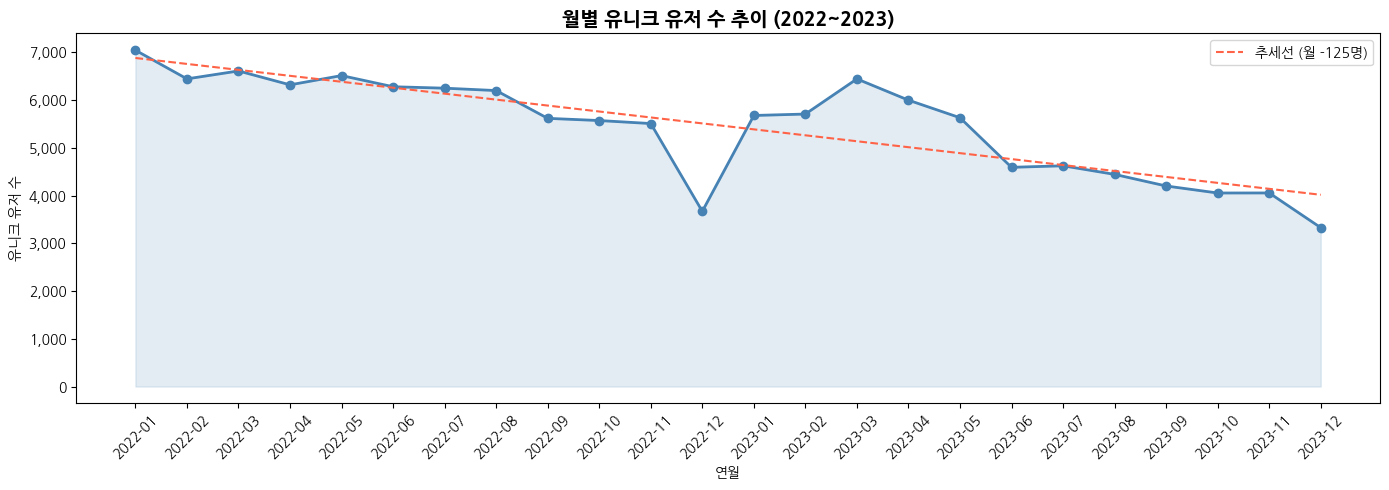

시작(2022-01): 7,046명
종료(2023-12): 3,329명
감소율: 52.8%


In [2]:
monthly_users = df[df['timestamp'].dt.year >= 2022].groupby('year_month')['user_uuid'].nunique().reset_index()
monthly_users.columns = ['year_month', 'unique_users']
monthly_users['year_month_str'] = monthly_users['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_users['year_month_str'], monthly_users['unique_users'],
        marker='o', linewidth=2, color='steelblue', markersize=6)
ax.fill_between(monthly_users['year_month_str'], monthly_users['unique_users'],
                alpha=0.15, color='steelblue')

import numpy as np
x = np.arange(len(monthly_users))
z = np.polyfit(x, monthly_users['unique_users'], 1)
p = np.poly1d(z)
ax.plot(monthly_users['year_month_str'], p(x),
        linestyle='--', color='tomato', linewidth=1.5, label=f'추세선 (월 {z[0]:+.0f}명)')

ax.set_title('월별 유니크 유저 수 추이 (2022~2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('연월')
ax.set_ylabel('유니크 유저 수')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"시작({monthly_users['year_month_str'].iloc[0]}): {monthly_users['unique_users'].iloc[0]:,}명")
print(f"종료({monthly_users['year_month_str'].iloc[-1]}): {monthly_users['unique_users'].iloc[-1]:,}명")
print(f"감소율: {(1 - monthly_users['unique_users'].iloc[-1] / monthly_users['unique_users'].iloc[0]) * 100:.1f}%")

#유저 세그먼트

In [4]:
# =========================================================================
# [2단계] URL 정규화 및 행동 분류
# =========================================================================

#19개
PASSIVE_NETWORK_URLS = {
    'people', 'search', 'suggest',
    'api/search/people/job_title', 'api/search/people/major', 'api/search/people/schools',
    'api/people/template',
    '@user_id', '@user_id/activities', '@user_id/preview',
    '@user_id/follower', '@user_id/following',
    'api/companies/company_id', 'api/companies/id',
    'api/companies/id/member_list', 'api/companies/id/reference_list',
    'api/companies/id/view',
    'api/post/id/template/viewers',
    '@user_id/notifications', 'api/users/notifications',
    'api/users/notifications/mark_read', 'api/users/notifications/mark_all_read',
    'companies/company_id', 'api/search/users', 'api/companies/id/bookmark',
}

#16개
ACTIVE_NETWORK_URLS = {
    'api/comapnies/id/follow_button', 'api/jobs/id/follow_button',
    'api/references', 'api/recommend_specialty',
    'api/companies/id/reference', 'api/companies/id/reference/id',
    'api/companies/id/reference/id/form',
    'api/users/id/request_button', 'api/users/id/reference/id/form',
    'api/users/id/reference/template',
    'api/users/id/friend_request_modal',
    '@user_id/job_offer/received', '@user_id/job_offer/sent',
    'api/job_offer/id/modal', 'api/job_offer/id/reject',
    'api/post/id', 'api/post/id/form',
}

#12개
PASSIVE_JOB_URLS = {
    'api/jobs/collections/template', 'api/jobs/id/other_jobs',
    'api/jobs/job_title', 'api/jobs/user_filter/id',
    'api/jobs/widget/widget_templates', 'api/search/people/job_title',
    'jobs/id/id_title', 'jobs', 'companies/company_id/jobs',
    'api/search/jobs/job_title', 'companies/company_id/jobs/job_title',
    'api/jobs/id/template_oneclick',
}

#11개
ACTIVE_JOB_URLS = {
    'api/jobs/id/apply/step1', 'api/jobs/id/apply/step2',
    'api/jobs/id/apply/step3', 'api/jobs/id/apply/step4',
    'api/jobs/id/bookmark', 'jobs/id/apply/step1',
    'jobs/id/apply/step2', 'jobs/id/apply/step3',
    'jobs/id/apply/step4', 'jobs/id/applications',
    'jobs/id/apply/complete',
}

def normalize_url(url):
    if not isinstance(url, str):
        return None
    u = url.lower().strip()
    u = re.sub(r'[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}', 'id', u)
    u = re.sub(r'(?<=/)\d+(?=/|$)', 'id', u)
    u = re.sub(r'^@[^/]+', '@user_id', u)
    return u

df['url_normalized'] = df['url_clean'].apply(normalize_url)
df['is_passive_network'] = df['url_normalized'].isin(PASSIVE_NETWORK_URLS)
df['is_active_network']  = df['url_normalized'].isin(ACTIVE_NETWORK_URLS)
df['is_passive_job']     = df['url_normalized'].isin(PASSIVE_JOB_URLS)
df['is_active_job']      = df['url_normalized'].isin(ACTIVE_JOB_URLS)

print(f"전체 로그: {len(df):,}행 / {df['user_uuid'].nunique():,}명")

# =========================================================================
# [3단계] 유저별 원본값 집계
# =========================================================================

analysis_date = pd.Timestamp('2023-12-31')

df_raw = (
    df.groupby('user_uuid')
    .agg(
        last_visit          = ('date', 'max'),
        passive_network_raw = ('is_passive_network', 'sum'),
        active_network_raw  = ('is_active_network',  'sum'),
        passive_job_raw     = ('is_passive_job',     'sum'),
        active_job_raw      = ('is_active_job',      'sum'),
    )
    .reset_index()
)

df_raw['R_raw'] = (analysis_date - df_raw['last_visit']).dt.days

print(f"유저 수: {len(df_raw):,}명")

# =========================================================================
# [4단계] 5분위 스코어링 (1~5점)
# =========================================================================

def make_score(series, ascending=True):
    labels = [1, 2, 3, 4, 5] if ascending else [5, 4, 3, 2, 1]
    return pd.qcut(series.rank(method='first'), q=5, labels=labels).astype(float)

df_raw['R_score']               = make_score(df_raw['R_raw'], ascending=False)
df_raw['passive_network_score'] = make_score(df_raw['passive_network_raw'])
df_raw['active_network_score']  = make_score(df_raw['active_network_raw'])
df_raw['passive_job_score']     = make_score(df_raw['passive_job_raw'])
df_raw['active_job_score']      = make_score(df_raw['active_job_raw'])

전체 로그: 15,235,505행 / 21,221명
유저 수: 21,221명


=== 네트워킹 세그먼트 분포 ===
                 count     %
network_segment             
1. 핵심 네트워킹        6539  30.8
2. 탐색 네트워킹        3076  14.5
3. 목적 네트워킹         255   1.2
4. 잠수 관찰자         2863  13.5
5. 휴면 유저          3329  15.7
6. 이탈 유저          5159  24.3

=== 세그먼트별 평균 점수 ===
                 R_score  passive_network_score  active_network_score
network_segment                                                      
1. 핵심 네트워킹          4.18                   4.36                  4.56
2. 탐색 네트워킹          3.91                   3.61                  2.56
3. 목적 네트워킹          3.84                   1.92                  4.10
4. 잠수 관찰자           3.71                   1.59                  1.80
5. 휴면 유저            1.65                   3.53                  3.41
6. 이탈 유저            1.40                   1.41                  1.64


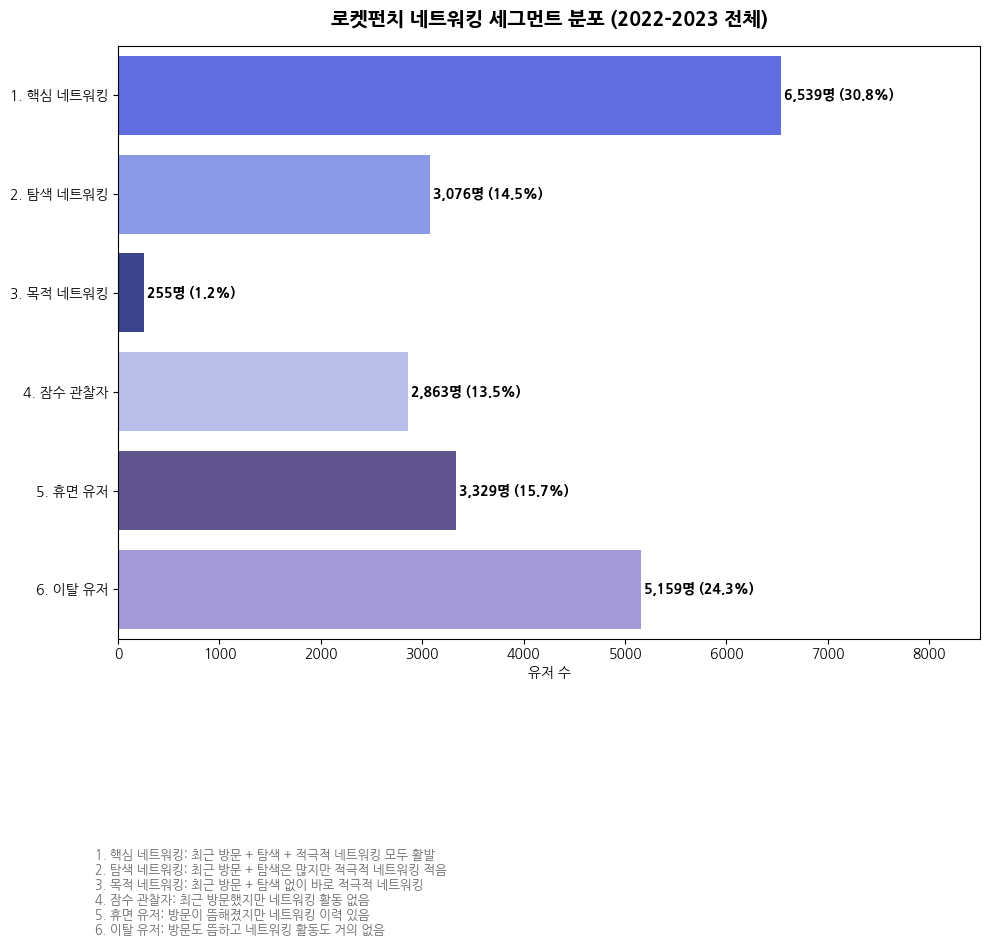

In [5]:
# =========================================================================
# [5단계] 네트워킹 세그먼트 + 시각화
# =========================================================================

def assign_network_segment(row):
    is_recent       = row['R_score'] >= 3.0
    is_high_passive = row['passive_network_score'] >= 3.0
    is_high_active  = row['active_network_score'] >= 4.0

    if is_recent and is_high_passive and is_high_active:
        return '1. 핵심 네트워킹'
    elif is_recent and is_high_passive and not is_high_active:
        return '2. 탐색 네트워킹'
    elif is_recent and not is_high_passive and is_high_active:
        return '3. 목적 네트워킹'
    elif is_recent and not is_high_passive and not is_high_active:
        return '4. 잠수 관찰자'
    elif not is_recent and (is_high_passive or is_high_active):
        return '5. 휴면 유저'
    else:
        return '6. 이탈 유저'

df_raw['network_segment'] = df_raw.apply(assign_network_segment, axis=1)

net_counts = df_raw['network_segment'].value_counts().sort_index()
net_pct    = df_raw['network_segment'].value_counts(normalize=True).sort_index().mul(100).round(1)
print("=== 네트워킹 세그먼트 분포 ===")
print(pd.DataFrame({'count': net_counts, '%': net_pct}))

print("\n=== 세그먼트별 평균 점수 ===")
print(df_raw.groupby('network_segment')[
    ['R_score', 'passive_network_score', 'active_network_score']
].mean().round(2))

color_map_net = {
    '1. 핵심 네트워킹':   '#4B5DF5',  # 메인 브랜드 블루
    '2. 탐색 네트워킹':   '#7B8FF7',  # 밝은 블루
    '3. 목적 네트워킹':   '#2E3A99',  # 진한 네이비
    '4. 잠수 관찰자':     '#B0B8F0',  # 연한 라벤더
    '5. 휴면 유저':       '#5B4B99',  # 블루-퍼플
    '6. 이탈 유저':       '#9C8FE0',  # 연한 퍼플
}

segment_desc_net = {
    '1. 핵심 네트워킹': '최근 방문 + 탐색 + 적극적 네트워킹 모두 활발',
    '2. 탐색 네트워킹':     '최근 방문 + 탐색은 많지만 적극적 네트워킹 적음',
    '3. 목적 네트워킹':  '최근 방문 + 탐색 없이 바로 적극적 네트워킹',
    '4. 잠수 관찰자':           '최근 방문했지만 네트워킹 활동 없음',
    '5. 휴면 유저':            '방문이 뜸해졌지만 네트워킹 이력 있음',
    '6. 이탈 유저':            '방문도 뜸하고 네트워킹 활동도 거의 없음',
}


fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=net_counts.values, y=net_counts.index,
            hue=net_counts.index, palette=color_map_net, legend=False, ax=ax)
total = net_counts.sum()
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        ax.text(width + 30, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,}명 ({width/total*100:.1f}%)',
                va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, net_counts.max() * 1.3)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('로켓펀치 네트워킹 세그먼트 분포 (2022-2023 전체)',
          fontsize=14, fontweight='bold', pad=15)
desc_text = '\n'.join([f'{k}: {v}' for k, v in segment_desc_net.items()])
plt.figtext(0.1, -0.22, desc_text, fontsize=9, verticalalignment='top', color='dimgray')
plt.tight_layout()
plt.show()

=== 구직활동 세그먼트 분포 ===
             count     %
job_segment             
1. 핵심 구직자     6323  29.8
2. 탐색 구직자     3068  14.5
3. 목적 구직자      118   0.6
4. 잠수 관찰자     3224  15.2
5. 휴면 유저      3543  16.7
6. 이탈 유저      4945  23.3

=== 세그먼트별 평균 점수 ===
             R_score  passive_job_score  active_job_score
job_segment                                              
1. 핵심 구직자       4.15               4.38              4.56
2. 탐색 구직자       3.98               3.53              2.43
3. 목적 구직자       3.79               1.93              4.11
4. 잠수 관찰자       3.74               1.58              1.76
5. 휴면 유저        1.62               3.61              3.54
6. 이탈 유저        1.41               1.42              1.76


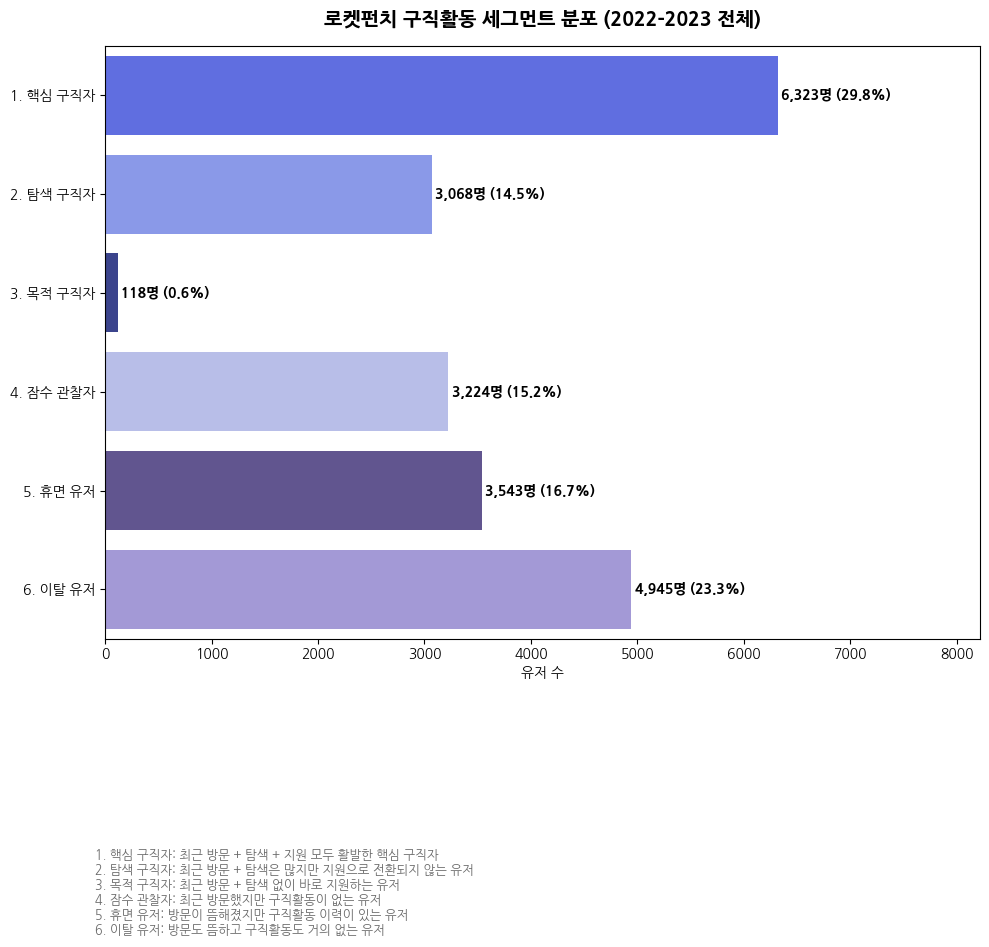

In [6]:
# =========================================================================
# [6단계] 구직활동 세그먼트 + 시각화
# =========================================================================

def assign_job_segment(row):
    is_recent       = row['R_score'] >= 3.0
    is_high_passive = row['passive_job_score'] >= 3.0
    is_high_active  = row['active_job_score'] >= 4.0

    if is_recent and is_high_passive and is_high_active:
        return '1. 핵심 구직자'
    elif is_recent and is_high_passive and not is_high_active:
        return '2. 탐색 구직자'
    elif is_recent and not is_high_passive and is_high_active:
        return '3. 목적 구직자'
    elif is_recent and not is_high_passive and not is_high_active:
        return '4. 잠수 관찰자'
    elif not is_recent and (is_high_passive or is_high_active):
        return '5. 휴면 유저'
    else:
        return '6. 이탈 유저'

df_raw['job_segment'] = df_raw.apply(assign_job_segment, axis=1)

job_counts = df_raw['job_segment'].value_counts().sort_index()
job_pct    = df_raw['job_segment'].value_counts(normalize=True).sort_index().mul(100).round(1)
print("=== 구직활동 세그먼트 분포 ===")
print(pd.DataFrame({'count': job_counts, '%': job_pct}))

print("\n=== 세그먼트별 평균 점수 ===")
print(df_raw.groupby('job_segment')[
    ['R_score', 'passive_job_score', 'active_job_score']
].mean().round(2))

color_map_job = {
    '1. 핵심 구직자':   '#4B5DF5',  # 메인 브랜드 블루
    '2. 탐색 구직자':   '#7B8FF7',  # 밝은 블루
    '3. 목적 구직자':   '#2E3A99',  # 진한 네이비
    '4. 잠수 관찰자':   '#B0B8F0',  # 연한 라벤더
    '5. 휴면 유저':     '#5B4B99',  # 블루-퍼플
    '6. 이탈 유저':     '#9C8FE0',  # 연한 퍼플
}

segment_desc_job = {
    '1. 핵심 구직자':      '최근 방문 + 탐색 + 지원 모두 활발한 핵심 구직자',
    '2. 탐색 구직자':     '최근 방문 + 탐색은 많지만 지원으로 전환되지 않는 유저',
    '3. 목적 구직자': '최근 방문 + 탐색 없이 바로 지원하는 유저',
    '4. 잠수 관찰자':        '최근 방문했지만 구직활동이 없는 유저',
    '5. 휴면 유저':         '방문이 뜸해졌지만 구직활동 이력이 있는 유저',
    '6. 이탈 유저':         '방문도 뜸하고 구직활동도 거의 없는 유저',
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=job_counts.values, y=job_counts.index,
            hue=job_counts.index, palette=color_map_job, legend=False, ax=ax)
total = job_counts.sum()
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        ax.text(width + 30, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,}명 ({width/total*100:.1f}%)',
                va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, job_counts.max() * 1.3)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('로켓펀치 구직활동 세그먼트 분포 (2022-2023 전체)',
          fontsize=14, fontweight='bold', pad=15)
desc_text = '\n'.join([f'{k}: {v}' for k, v in segment_desc_job.items()])
plt.figtext(0.1, -0.22, desc_text, fontsize=9, verticalalignment='top', color='dimgray')
plt.tight_layout()
plt.show()

- 네트워킹·구직활동 세그먼트는 분류 기준이 동일해 분포가 유사한 것뿐 아니라, 마지막 네트워킹 활동일과 마지막 구직 활동일을 각각 기준으로 분리해 재분류했을 때도 분포가 거의 동일하게 나타났다. 이는 두 활동의 마지막 시점이 유저별로 거의 일치함을 의미하며, 유저들이 사이트 방문 시 네트워킹과 구직 탐색/지원을 한 세션 안에서 함께 수행하는 경향이 있음을 시사한다.
- 따라서 두 세그먼트의 실질적 차이는 최근성이 아닌 영역별 활동 강도(passive vs active)에서 발생한다.

##세그먼트별 유지율

=== 네트워킹 세그먼트별 월별 잔류율 ===
                   1. 핵심 네트워킹  2. 탐색 네트워킹  3. 목적 네트워킹  4. 잠수 관찰자  5. 휴면 유저  \
months_since_join                                                            
0                       100.0       100.0       100.0      100.0     100.0   
1                        76.6        60.7        54.9       26.4      68.7   
2                        69.1        52.6        37.3       18.2      52.3   
3                        61.7        45.7        16.9       15.2      43.6   
4                        57.5        44.4        16.9       12.3      36.3   
5                        53.0        41.6        18.4       11.8      31.6   
6                        50.8        39.2        16.1       11.0      29.3   
7                        48.8        37.2        14.5        9.2      25.8   
8                        45.6        33.8        13.7        8.9      20.5   
9                        45.0        31.4        11.0        8.6      17.9   
10                       42.0        3

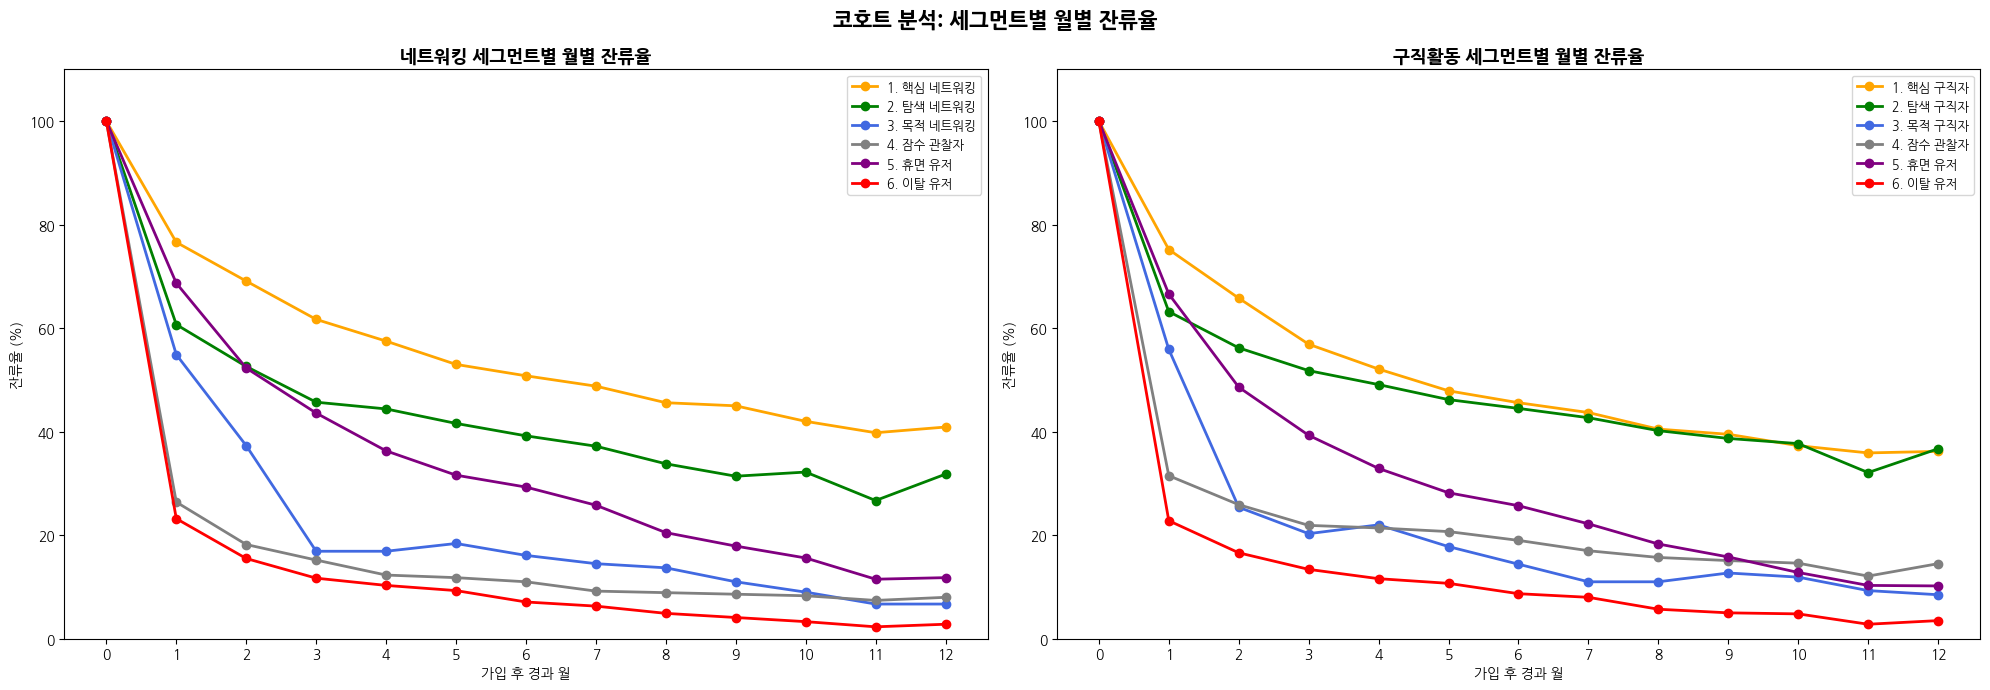

In [7]:
# =========================================================================
# [코호트 분석] 세그먼트별 월별 잔류율
# =========================================================================

seg_df = df_raw[['user_uuid', 'network_segment', 'job_segment']].drop_duplicates('user_uuid')

# 유저별 첫 방문 월
first_visit = (
    df.groupby('user_uuid')['date']
    .min()
    .reset_index()
)
first_visit.columns = ['user_uuid', 'first_date']
first_visit['cohort_month'] = pd.to_datetime(first_visit['first_date']).dt.to_period('M')

# 유저별 월별 활동
user_monthly = (
    df.groupby(['user_uuid', df['date'].dt.to_period('M')])
    .size()
    .reset_index()
)
user_monthly.columns = ['user_uuid', 'activity_month', 'log_count']
user_monthly = user_monthly.merge(first_visit[['user_uuid', 'cohort_month']], on='user_uuid', how='left')
user_monthly = user_monthly.merge(seg_df, on='user_uuid', how='left')
user_monthly['months_since_join'] = (
    user_monthly['activity_month'] - user_monthly['cohort_month']
).apply(lambda x: x.n)
user_monthly = user_monthly[user_monthly['months_since_join'].between(0, 12)]

# 잔류율 계산 함수
def calc_monthly_retention(data, col, segments):
    ret = {}
    for label, seg in segments.items():
        group = data[data[col] == seg]
        total = group[group['months_since_join'] == 0]['user_uuid'].nunique()
        if total > 0:
            ret[label] = (
                group.groupby('months_since_join')['user_uuid']
                .nunique()
                .div(total)
                .mul(100)
                .round(1)
            )
    return pd.DataFrame(ret).fillna(0)

net_segments = {
    '1. 핵심 네트워킹': '1. 핵심 네트워킹',
    '2. 탐색 네트워킹': '2. 탐색 네트워킹',
    '3. 목적 네트워킹': '3. 목적 네트워킹',
    '4. 잠수 관찰자':   '4. 잠수 관찰자',
    '5. 휴면 유저':     '5. 휴면 유저',
    '6. 이탈 유저':     '6. 이탈 유저',
}

job_segments = {
    '1. 핵심 구직자': '1. 핵심 구직자',
    '2. 탐색 구직자': '2. 탐색 구직자',
    '3. 목적 구직자': '3. 목적 구직자',
    '4. 잠수 관찰자': '4. 잠수 관찰자',
    '5. 휴면 유저':   '5. 휴면 유저',
    '6. 이탈 유저':   '6. 이탈 유저',
}

net_ret_df = calc_monthly_retention(user_monthly, 'network_segment', net_segments)
job_ret_df = calc_monthly_retention(user_monthly, 'job_segment', job_segments)

print("=== 네트워킹 세그먼트별 월별 잔류율 ===")
print(net_ret_df)
print("\n=== 구직활동 세그먼트별 월별 잔류율 ===")
print(job_ret_df)

# 시각화
colors = ['orange', 'green', 'royalblue', 'gray', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for col, color in zip(net_ret_df.columns, colors):
    axes[0].plot(net_ret_df.index, net_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[0].set_title('네트워킹 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가입 후 경과 월')
axes[0].set_ylabel('잔류율 (%)')
axes[0].set_xticks(range(0, 13))
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9)

for col, color in zip(job_ret_df.columns, colors):
    axes[1].plot(job_ret_df.index, job_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[1].set_title('구직활동 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가입 후 경과 월')
axes[1].set_ylabel('잔류율 (%)')
axes[1].set_xticks(range(0, 13))
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)

plt.suptitle('코호트 분석: 세그먼트별 월별 잔류율', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

=== 네트워킹 세그먼트별 월별 잔류율 ===
                   1. 핵심 네트워킹  2. 탐색 네트워킹  3. 목적 네트워킹  4. 잠수 관찰자  5. 휴면 유저  \
months_since_join                                                            
0                       100.0       100.0       100.0      100.0     100.0   
1                        73.8        59.2        49.5       28.4      68.6   
2                        69.1        54.7        40.6       24.3      53.7   
3                        65.4        49.5        20.8       20.8      45.7   
4                        64.5        50.0        26.7       17.8      38.3   
5                        61.5        47.6        30.7       17.7      33.3   
6                        60.3        45.4        28.7       17.3      30.9   
7                        59.2        43.3        28.7       15.2      27.2   
8                        56.5        39.7        25.7       15.9      21.6   
9                        57.1        37.1        21.8       15.1      18.9   
10                       54.2        3

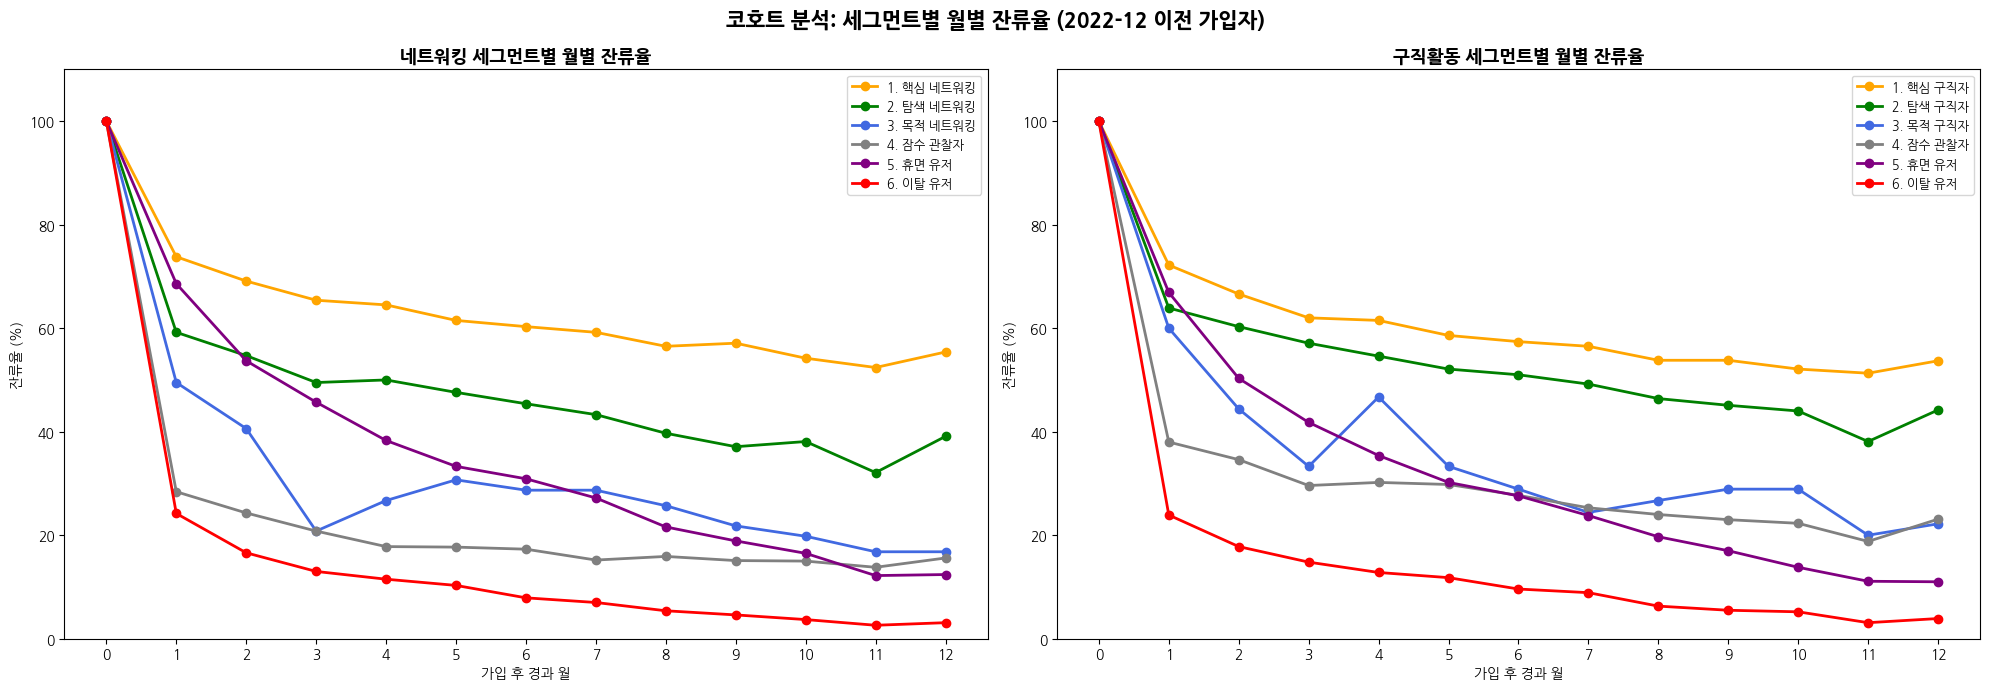

In [8]:
# 12개월 추적 가능한 코호트만 사용 (2022-12 이전 가입자)
valid_cohorts = first_visit[
    first_visit['cohort_month'] <= pd.Period('2022-12', 'M')
]['user_uuid']

user_monthly_filtered = user_monthly[user_monthly['user_uuid'].isin(valid_cohorts)]

net_ret_df = calc_monthly_retention(user_monthly_filtered, 'network_segment', net_segments)
job_ret_df = calc_monthly_retention(user_monthly_filtered, 'job_segment', job_segments)

print("=== 네트워킹 세그먼트별 월별 잔류율 ===")
print(net_ret_df)
print("\n=== 구직활동 세그먼트별 월별 잔류율 ===")
print(job_ret_df)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

colors = ['orange', 'green', 'royalblue', 'gray', 'purple', 'red']

for col, color in zip(net_ret_df.columns, colors):
    axes[0].plot(net_ret_df.index, net_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[0].set_title('네트워킹 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가입 후 경과 월')
axes[0].set_ylabel('잔류율 (%)')
axes[0].set_xticks(range(0, 13))
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9)

for col, color in zip(job_ret_df.columns, colors):
    axes[1].plot(job_ret_df.index, job_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[1].set_title('구직활동 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가입 후 경과 월')
axes[1].set_ylabel('잔류율 (%)')
axes[1].set_xticks(range(0, 13))
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)

plt.suptitle('코호트 분석: 세그먼트별 월별 잔류율 (2022-12 이전 가입자)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

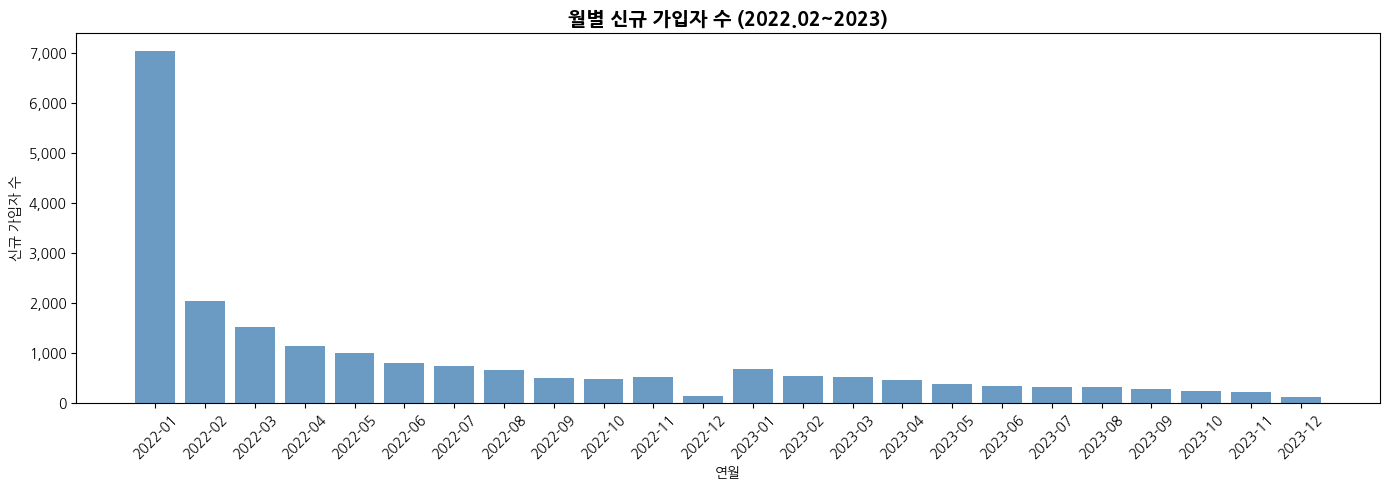

cohort_month_str  new_users
         2022-01       7045
         2022-02       2047
         2022-03       1531
         2022-04       1141
         2022-05       1015
         2022-06        805
         2022-07        751
         2022-08        669
         2022-09        507
         2022-10        494
         2022-11        518
         2022-12        152
         2023-01        694
         2023-02        556
         2023-03        531
         2023-04        476
         2023-05        392
         2023-06        356
         2023-07        319
         2023-08        320
         2023-09        282
         2023-10        254
         2023-11        232
         2023-12        134


In [11]:
new_users_monthly = (
    first_visit.groupby('cohort_month')['user_uuid']
    .nunique()
    .reset_index()
)
new_users_monthly.columns = ['cohort_month', 'new_users']
new_users_monthly['cohort_month_str'] = new_users_monthly['cohort_month'].astype(str)

# 2022-02 이후만
new_users_monthly = new_users_monthly[
    new_users_monthly['cohort_month'] >= pd.Period('2022-01', 'M')
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(new_users_monthly['cohort_month_str'], new_users_monthly['new_users'],
       color='steelblue', alpha=0.8)
ax.set_title('월별 신규 가입자 수 (2022.02~2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('연월')
ax.set_ylabel('신규 가입자 수')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(new_users_monthly[['cohort_month_str', 'new_users']].to_string(index=False))

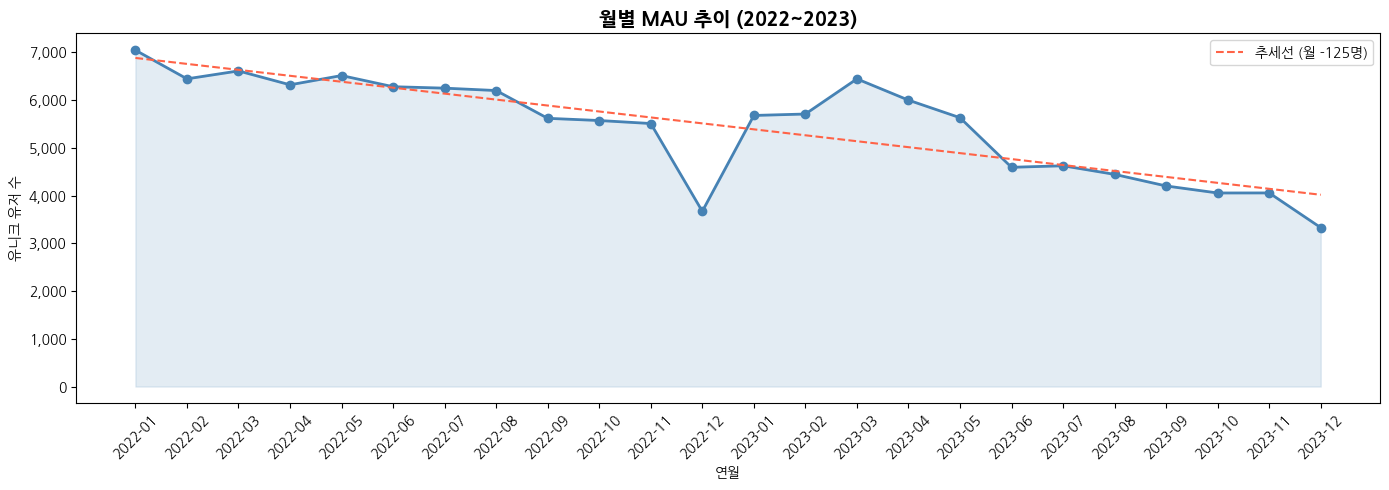

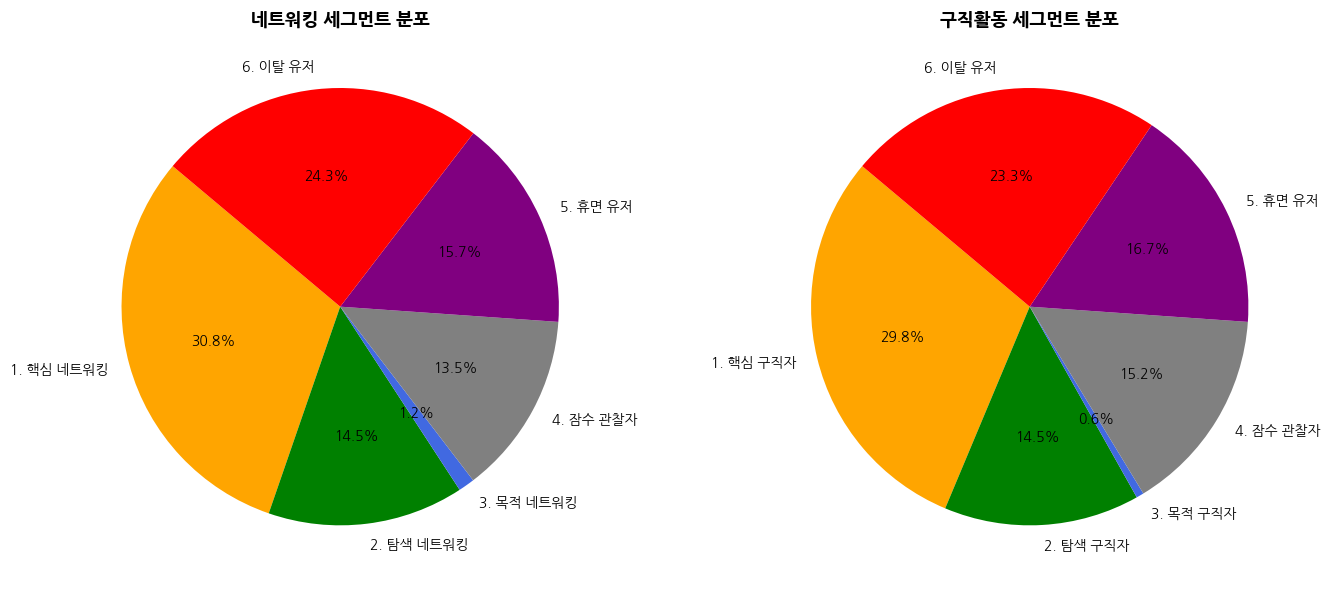

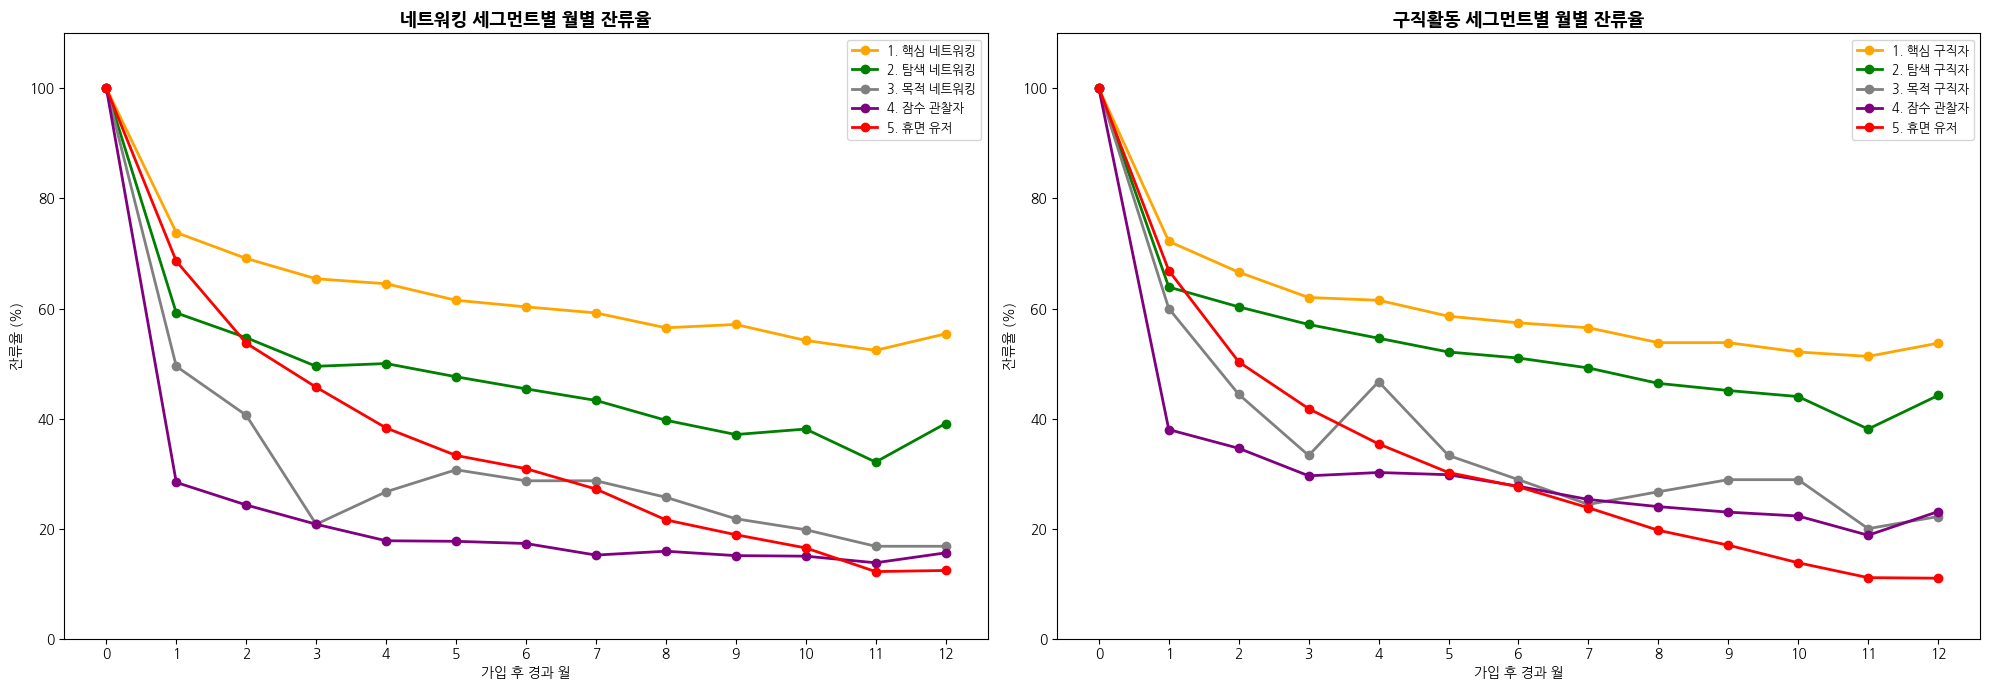

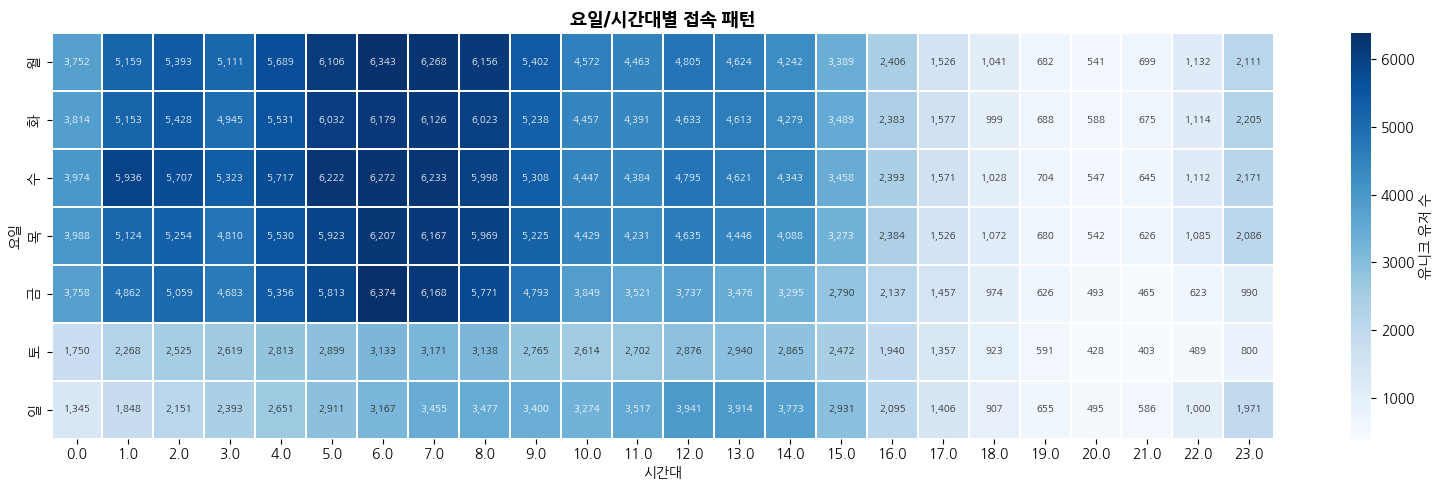

In [13]:
# ① 월별 MAU 추이
fig1, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_users['year_month_str'], monthly_users['unique_users'],
        marker='o', linewidth=2, color='steelblue', markersize=6)
ax.fill_between(monthly_users['year_month_str'], monthly_users['unique_users'],
                alpha=0.15, color='steelblue')
x = np.arange(len(monthly_users))
z = np.polyfit(x, monthly_users['unique_users'], 1)
p = np.poly1d(z)
ax.plot(monthly_users['year_month_str'], p(x),
        linestyle='--', color='tomato', linewidth=1.5, label=f'추세선 (월 {z[0]:+.0f}명)')
ax.set_title('월별 MAU 추이 (2022~2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('연월')
ax.set_ylabel('유니크 유저 수')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# ② 세그먼트 분포
fig2, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['orange', 'green', 'royalblue', 'gray', 'purple', 'red']

seg_dist = df_raw.groupby('network_segment')['user_uuid'].nunique().reset_index()
seg_dist.columns = ['세그먼트', '유저수']
axes[0].pie(seg_dist['유저수'], labels=seg_dist['세그먼트'],
            autopct='%1.1f%%', startangle=140, colors=colors)
axes[0].set_title('네트워킹 세그먼트 분포', fontsize=13, fontweight='bold')

job_dist = df_raw.groupby('job_segment')['user_uuid'].nunique().reset_index()
job_dist.columns = ['세그먼트', '유저수']
axes[1].pie(job_dist['유저수'], labels=job_dist['세그먼트'],
            autopct='%1.1f%%', startangle=140, colors=colors)
axes[1].set_title('구직활동 세그먼트 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ③ 세그먼트별 월별 잔류율
fig3, axes = plt.subplots(1, 2, figsize=(20, 7))
ret_colors = ['orange', 'green', 'gray', 'purple', 'red']

for col, color in zip(net_ret_df.columns, ret_colors):
    axes[0].plot(net_ret_df.index, net_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[0].set_title('네트워킹 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가입 후 경과 월')
axes[0].set_ylabel('잔류율 (%)')
axes[0].set_xticks(range(0, 13))
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9)

for col, color in zip(job_ret_df.columns, ret_colors):
    axes[1].plot(job_ret_df.index, job_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[1].set_title('구직활동 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가입 후 경과 월')
axes[1].set_ylabel('잔류율 (%)')
axes[1].set_xticks(range(0, 13))
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# ④ 요일/시간대별 접속 패턴
df['요일'] = df['timestamp'].dt.dayofweek
df['시간대'] = df['timestamp'].dt.hour
heatmap_data = df.groupby(['요일', '시간대'])['user_uuid'].nunique().unstack()
heatmap_data.index = ['월', '화', '수', '목', '금', '토', '일']

fig4, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='Blues', ax=ax,
            fmt=',d', annot=True, annot_kws={'size': 7},
            linewidths=0.3, cbar_kws={'label': '유니크 유저 수'})
ax.set_title('요일/시간대별 접속 패턴', fontsize=13, fontweight='bold')
ax.set_xlabel('시간대')
ax.set_ylabel('요일')
plt.tight_layout()
plt.show()

##   1. 네트워킹 & 구직활동 상관분석



=== 구직활동 × 네트워킹 세그먼트 교차표 ===


network_segment,1. 핵심 네트워킹,2. 탐색 네트워킹,3. 목적 네트워킹,4. 잠수 관찰자,5. 휴면 유저,6. 이탈 유저
job_segment,,,,,,
1. 핵심 구직자,5274,745,148,156,0,0
2. 탐색 구직자,1029,1482,36,521,0,0
3. 목적 구직자,27,21,26,44,0,0
4. 잠수 관찰자,209,828,45,2142,0,0
5. 휴면 유저,0,0,0,0,2634,909
6. 이탈 유저,0,0,0,0,695,4250


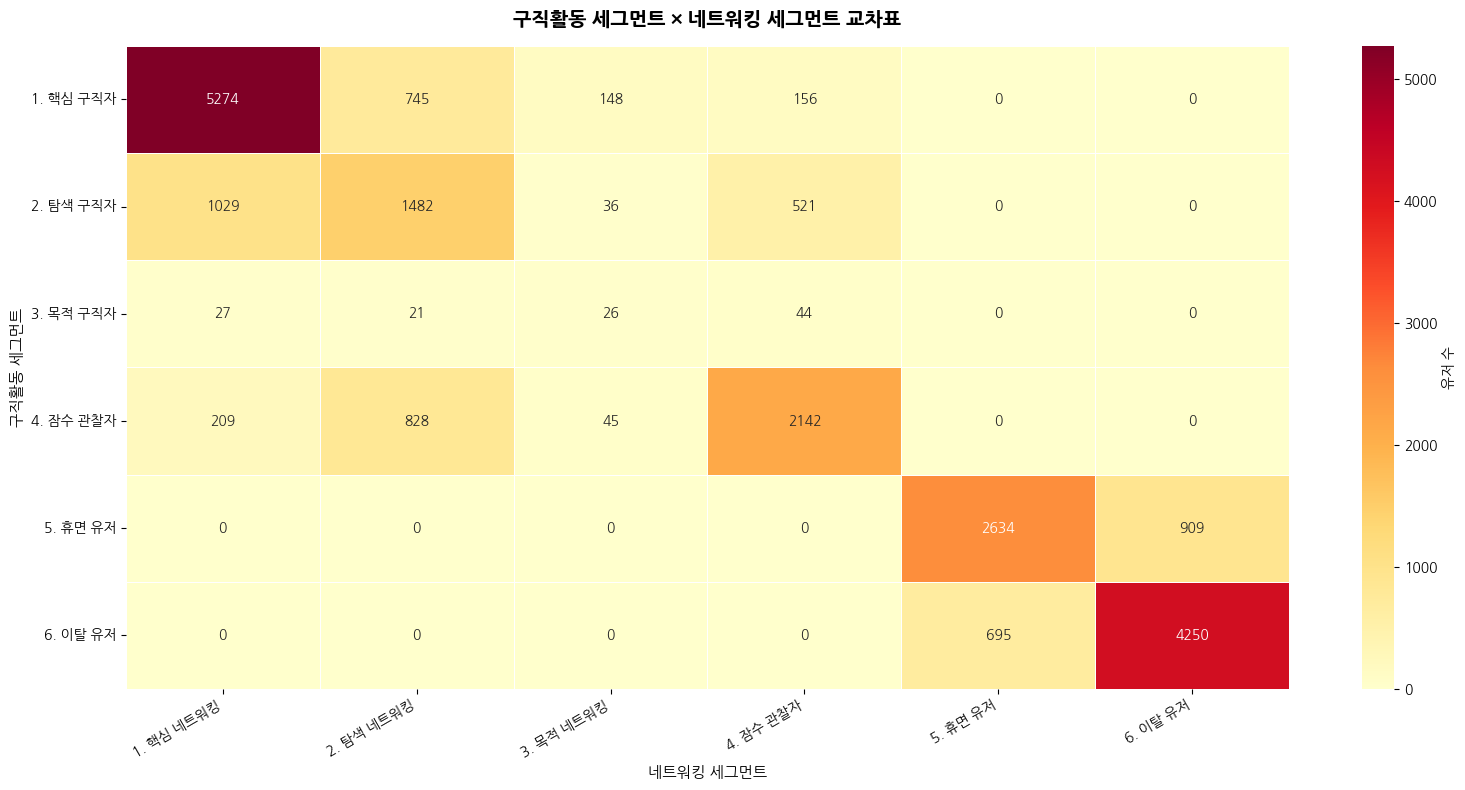

In [14]:
# =========================================================================
# [7단계] 교차표 + 히트맵
# =========================================================================

print("=== 구직활동 × 네트워킹 세그먼트 교차표 ===")
cross = pd.crosstab(df_raw['job_segment'], df_raw['network_segment'])
display(cross)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    cross,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': '유저 수'}
)
plt.title('구직활동 세그먼트 × 네트워킹 세그먼트 교차표',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('네트워킹 세그먼트', fontsize=11)
plt.ylabel('구직활동 세그먼트', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== 네트워킹 세그먼트 내 구직활동 비율 (열 기준 %) ===


network_segment,1. 핵심 네트워킹,2. 탐색 네트워킹,3. 목적 네트워킹,4. 잠수 관찰자,5. 휴면 유저,6. 이탈 유저
job_segment,,,,,,
1. 핵심 구직자,80.7,24.2,58.0,5.4,0.0,0.0
2. 탐색 구직자,15.7,48.2,14.1,18.2,0.0,0.0
3. 목적 구직자,0.4,0.7,10.2,1.5,0.0,0.0
4. 잠수 관찰자,3.2,26.9,17.6,74.8,0.0,0.0
5. 휴면 유저,0.0,0.0,0.0,0.0,79.1,17.6
6. 이탈 유저,0.0,0.0,0.0,0.0,20.9,82.4



=== 구직활동 세그먼트 내 네트워킹 비율 (행 기준 %) ===


network_segment,1. 핵심 네트워킹,2. 탐색 네트워킹,3. 목적 네트워킹,4. 잠수 관찰자,5. 휴면 유저,6. 이탈 유저
job_segment,,,,,,
1. 핵심 구직자,83.4,11.8,2.3,2.5,0.0,0.0
2. 탐색 구직자,33.5,48.3,1.2,17.0,0.0,0.0
3. 목적 구직자,22.9,17.8,22.0,37.3,0.0,0.0
4. 잠수 관찰자,6.5,25.7,1.4,66.4,0.0,0.0
5. 휴면 유저,0.0,0.0,0.0,0.0,74.3,25.7
6. 이탈 유저,0.0,0.0,0.0,0.0,14.1,85.9


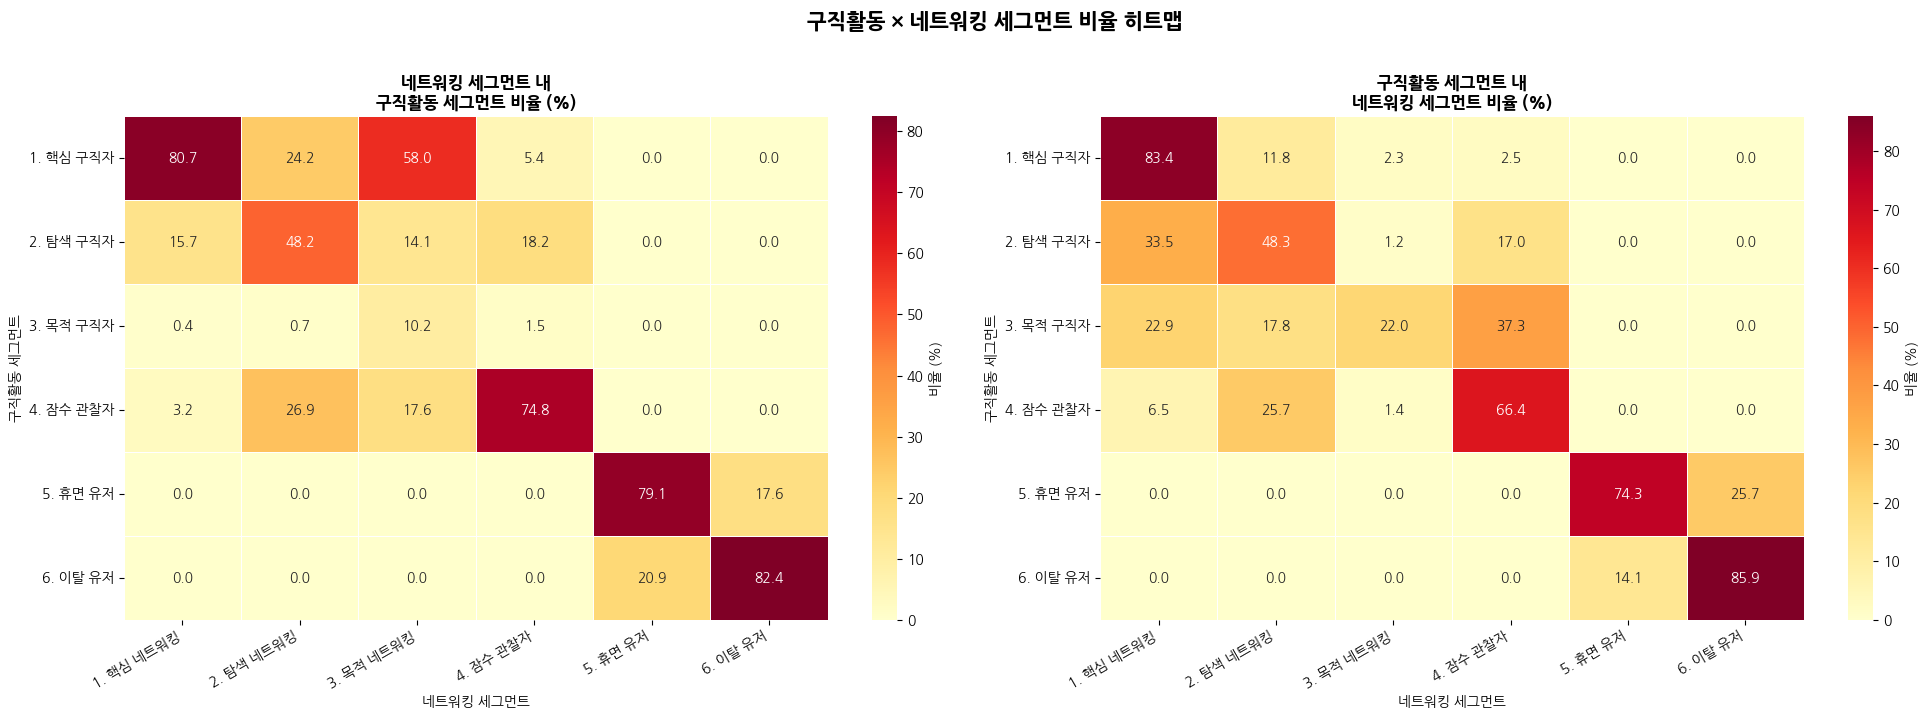

In [15]:
# =========================================================================
# 네트워크 유저 대비 구직자 비율 히트맵
# =========================================================================

# 교차표 다시 생성
cross = pd.crosstab(df_raw['job_segment'], df_raw['network_segment'])

# 비율 계산 (각 네트워킹 세그먼트 내에서 구직활동 세그먼트 비율)
cross_pct_col = cross.div(cross.sum(axis=0), axis=1).mul(100).round(1)

# 비율 계산 (각 구직활동 세그먼트 내에서 네트워킹 세그먼트 비율)
cross_pct_row = cross.div(cross.sum(axis=1), axis=0).mul(100).round(1)

print("=== 네트워킹 세그먼트 내 구직활동 비율 (열 기준 %) ===")
display(cross_pct_col)

print("\n=== 구직활동 세그먼트 내 네트워킹 비율 (행 기준 %) ===")
display(cross_pct_row)

# =========================================================================
# 시각화: 두 가지 비율 히트맵
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 열 기준 (네트워킹 세그먼트 내 구직활동 비율)
sns.heatmap(
    cross_pct_col,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={'label': '비율 (%)'}
)
axes[0].set_title('네트워킹 세그먼트 내\n구직활동 세그먼트 비율 (%)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('네트워킹 세그먼트')
axes[0].set_ylabel('구직활동 세그먼트')
axes[0].set_xticklabels(
    [x.get_text().split('(')[0].strip() for x in axes[0].get_xticklabels()],
    rotation=30, ha='right'
)
axes[0].set_yticklabels(
    [y.get_text().split('(')[0].strip() for y in axes[0].get_yticklabels()],
    rotation=0
)

# 행 기준 (구직활동 세그먼트 내 네트워킹 비율)
sns.heatmap(
    cross_pct_row,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=axes[1],
    linewidths=0.5,
    cbar_kws={'label': '비율 (%)'}
)
axes[1].set_title('구직활동 세그먼트 내\n네트워킹 세그먼트 비율 (%)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('네트워킹 세그먼트')
axes[1].set_ylabel('구직활동 세그먼트')
axes[1].set_xticklabels(
    [x.get_text().split('(')[0].strip() for x in axes[1].get_xticklabels()],
    rotation=30, ha='right'
)
axes[1].set_yticklabels(
    [y.get_text().split('(')[0].strip() for y in axes[1].get_yticklabels()],
    rotation=0
)

plt.suptitle('구직활동 × 네트워킹 세그먼트 비율 히트맵',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- 관심/방문은 있는데 핵심 행동을 하지 않는 2번(탐색형)
- 관심/방문은 하는데 아무런 행동을 하지않은 4번(잠수 관찰자)
- 이전에 활발히 활동했던 유저인5번(휴면)

을 타겟으로 자원을 투입하는 게 전환 비용 대비 효과가 크므로 ROI가 좋음

#CRM 및 리텐션 전략

##타겟 세그먼트 1 : 전체 유저

###가설 : 가입 후 7일 이내 프로필 작성 여부가 이후 유저의 활동 패턴과 관련 있을 것이다.

- 프로필 작성은 초기 온보딩에서 유저를 핵심/이탈로 가르는 분기점으로 가정

has_profile
True     10744
False    10477
Name: count, dtype: int64
프로필 작성률 (가입 후 7일 이내): 50.6%

프로필 작성 유저: 10,744명
프로필 미작성 유저: 10,477명

=== 네트워킹 세그먼트 분포 비교 (%) ===
                 프로필 작성  프로필 미작성
network_segment                 
1. 핵심 네트워킹         39.9     21.5
2. 탐색 네트워킹         11.6     17.4
3. 목적 네트워킹          1.9      0.5
4. 잠수 관찰자           9.9     17.2
5. 휴면 유저           19.7     11.5
6. 이탈 유저           17.0     31.8

=== 구직활동 세그먼트 분포 비교 (%) ===
             프로필 작성  프로필 미작성
job_segment                 
1. 핵심 구직자      40.8     18.5
2. 탐색 구직자      11.6     17.4
3. 목적 구직자       0.9      0.2
4. 잠수 관찰자       9.9     20.6
5. 휴면 유저       21.8     11.5
6. 이탈 유저       15.0     31.9


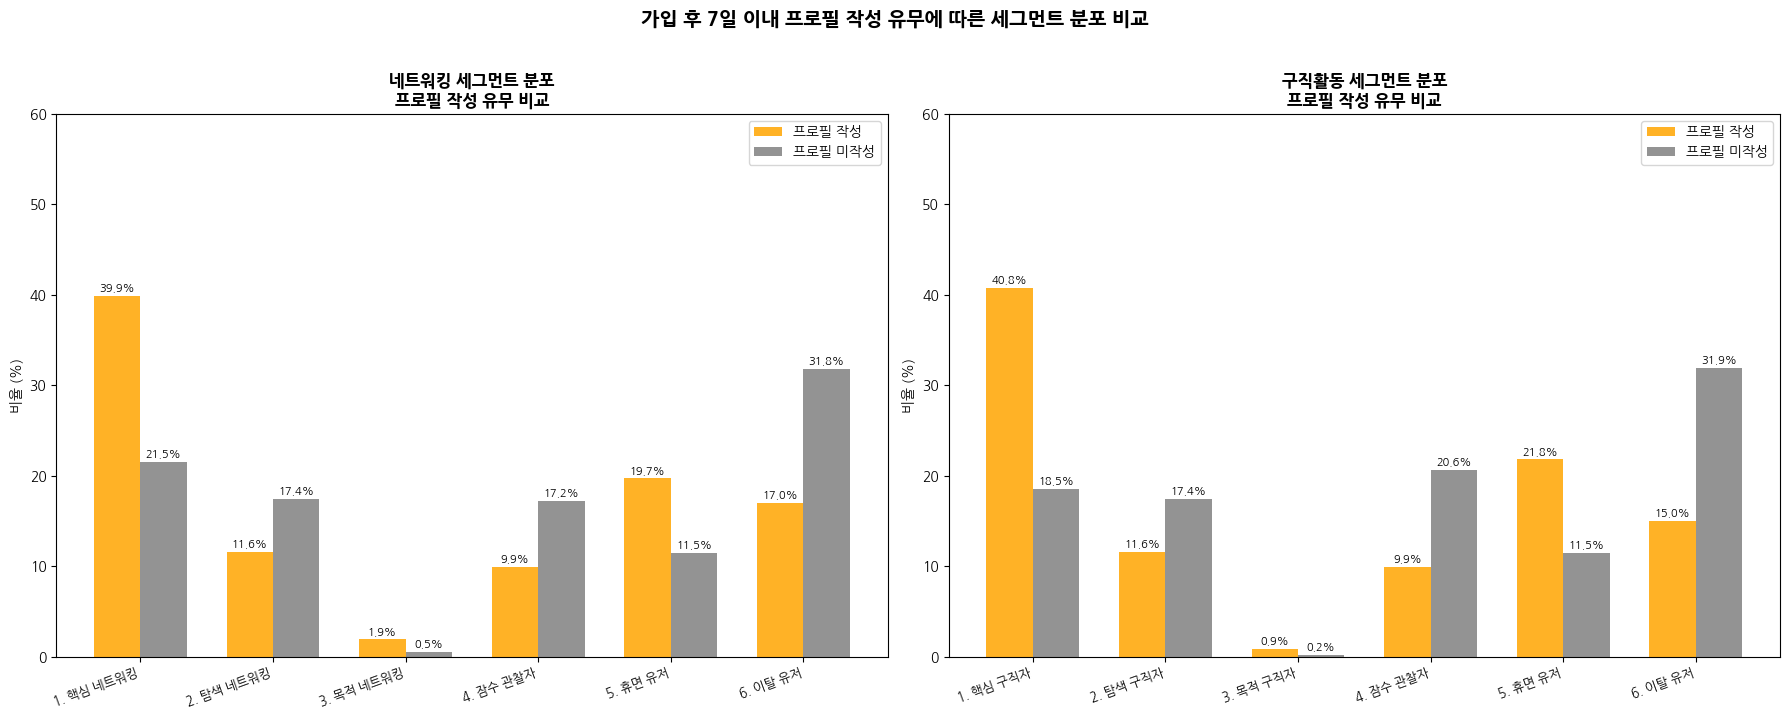


=== 핵심 유저 비율 비교 ===
핵심 네트워킹 비율 - 프로필 작성: 39.9% / 미작성: 21.5%
핵심 구직자 비율   - 프로필 작성: 40.8% / 미작성: 18.5%

프로필 작성 시 핵심 네트워킹 될 비율 차이: 18.5%p
프로필 작성 시 핵심 구직자 될 비율 차이:   22.3%p

[카이제곱 검정] 핵심 네트워킹 x 프로필 작성: chi2=847.31, p=0.0000
[카이제곱 검정] 핵심 구직자 x 프로필 작성: chi2=1261.76, p=0.0000


In [16]:
PROFILE_URLS = {
    'api/users/email', 'api/users/id/award', 'api/users/id/career',
    'api/users/id/certification', 'api/users/id/education', 'api/users/id/language',
    'api/users/id/overview', 'api/users/id/phone/verify', 'api/users/id/profile_image',
    'api/users/id/profile_image/facebook', 'api/users/id/project', 'api/users/id/residence',
    'api/users/id/resume/step1', 'api/users/id/resume/step2', 'api/users/id/sns',
    'api/users/id/specialty', 'api/users/id/specialty/id/vote',
    'api/project/form_data/media', 'api/projects/id/media/add', 'api/users/id/experience/form',
    '@user_id/resume', 'api/users/id/career/template', 'api/users/id/project/template',
    'api/users/id/career/id/form', 'api/users/id/career/id', '@users/id/resume/step1',
    'api/users/id/project/id/form', 'api/users/id/project/id', '@users/id/resume/step2',
    'api/users/id/project', 'api/users/education/template', 'api/users/id/certification/template',
    'api/users/id/image', 'api/users/id/language/form', 'api/users/id/award/template',
    'api/users/id/specialty/template',
}

# 가입 후 7일 이내 프로필 작성 여부
first_log = df.groupby('user_uuid')['date'].min().reset_index().rename(columns={'date': 'first_date'})

profile_logs = df[df['url_normalized'].isin(PROFILE_URLS)]
profile_first = profile_logs.groupby('user_uuid')['date'].min().reset_index().rename(columns={'date': 'profile_date'})

early_behavior = df_raw.merge(first_log, on='user_uuid', how='left')
early_behavior = early_behavior.merge(profile_first, on='user_uuid', how='left')

early_behavior['days_to_profile'] = (early_behavior['profile_date'] - early_behavior['first_date']).dt.days
early_behavior['has_profile'] = (
    (early_behavior['days_to_profile'] >= 0) & (early_behavior['days_to_profile'] <= 7)
).fillna(False)

print(early_behavior['has_profile'].value_counts())
print(f"프로필 작성률 (가입 후 7일 이내): {early_behavior['has_profile'].mean():.1%}")


# =========================================================================
# 프로필 작성 유무에 따른 세그먼트 분포 비교
# =========================================================================

profile_yes = early_behavior[early_behavior['has_profile'] == True]
profile_no  = early_behavior[early_behavior['has_profile'] == False]

print(f"\n프로필 작성 유저: {len(profile_yes):,}명")
print(f"프로필 미작성 유저: {len(profile_no):,}명")

net_profile_yes = profile_yes['network_segment'].value_counts(normalize=True).mul(100).round(1)
net_profile_no  = profile_no['network_segment'].value_counts(normalize=True).mul(100).round(1)

net_compare = pd.DataFrame({
    '프로필 작성': net_profile_yes,
    '프로필 미작성': net_profile_no,
}).fillna(0).sort_index()

print("\n=== 네트워킹 세그먼트 분포 비교 (%) ===")
print(net_compare)

job_profile_yes = profile_yes['job_segment'].value_counts(normalize=True).mul(100).round(1)
job_profile_no  = profile_no['job_segment'].value_counts(normalize=True).mul(100).round(1)

job_compare = pd.DataFrame({
    '프로필 작성': job_profile_yes,
    '프로필 미작성': job_profile_no,
}).fillna(0).sort_index()

print("\n=== 구직활동 세그먼트 분포 비교 (%) ===")
print(job_compare)


# =========================================================================
# 시각화
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

x = net_compare.index.tolist()
x_pos = range(len(x))
width = 0.35

bars1 = axes[0].bar([p - width/2 for p in x_pos], net_compare['프로필 작성'],
                     width=width, label='프로필 작성', color='orange', alpha=0.85)
bars2 = axes[0].bar([p + width/2 for p in x_pos], net_compare['프로필 미작성'],
                     width=width, label='프로필 미작성', color='gray', alpha=0.85)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([x.split('(')[0].strip() for x in net_compare.index],
                          rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('비율 (%)')
axes[0].set_ylim(0, 60)
axes[0].legend()
axes[0].set_title('네트워킹 세그먼트 분포\n프로필 작성 유무 비교', fontsize=12, fontweight='bold')

x2 = job_compare.index.tolist()
x_pos2 = range(len(x2))

bars3 = axes[1].bar([p - width/2 for p in x_pos2], job_compare['프로필 작성'],
                     width=width, label='프로필 작성', color='orange', alpha=0.85)
bars4 = axes[1].bar([p + width/2 for p in x_pos2], job_compare['프로필 미작성'],
                     width=width, label='프로필 미작성', color='gray', alpha=0.85)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels([x.split('(')[0].strip() for x in job_compare.index],
                          rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('비율 (%)')
axes[1].set_ylim(0, 60)
axes[1].legend()
axes[1].set_title('구직활동 세그먼트 분포\n프로필 작성 유무 비교', fontsize=12, fontweight='bold')

plt.suptitle('가입 후 7일 이내 프로필 작성 유무에 따른 세그먼트 분포 비교',
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# =========================================================================
# 핵심 유저 비율 비교 + 통계 검정
# =========================================================================

from scipy.stats import chi2_contingency

core_profile_yes = (profile_yes['network_segment'] == '1. 핵심 네트워킹').mean() * 100
core_profile_no  = (profile_no['network_segment']  == '1. 핵심 네트워킹').mean() * 100

active_profile_yes = (profile_yes['job_segment'] == '1. 핵심 구직자').mean() * 100
active_profile_no  = (profile_no['job_segment']  == '1. 핵심 구직자').mean() * 100

print("\n=== 핵심 유저 비율 비교 ===")
print(f"핵심 네트워킹 비율 - 프로필 작성: {core_profile_yes:.1f}% / 미작성: {core_profile_no:.1f}%")
print(f"핵심 구직자 비율   - 프로필 작성: {active_profile_yes:.1f}% / 미작성: {active_profile_no:.1f}%")
print(f"\n프로필 작성 시 핵심 네트워킹 될 비율 차이: {core_profile_yes - core_profile_no:.1f}%p")
print(f"프로필 작성 시 핵심 구직자 될 비율 차이:   {active_profile_yes - active_profile_no:.1f}%p")

# 통계 검정
table_net = pd.crosstab(early_behavior['has_profile'], early_behavior['network_segment'] == '1. 핵심 네트워킹')
chi2_net, p_net, _, _ = chi2_contingency(table_net)
print(f"\n[카이제곱 검정] 핵심 네트워킹 x 프로필 작성: chi2={chi2_net:.2f}, p={p_net:.4f}")

table_job = pd.crosstab(early_behavior['has_profile'], early_behavior['job_segment'] == '1. 핵심 구직자')
chi2_job, p_job, _, _ = chi2_contingency(table_job)
print(f"[카이제곱 검정] 핵심 구직자 x 프로필 작성: chi2={chi2_job:.2f}, p={p_job:.4f}")

일치 유저 수: 15,808명
net_level
1    5274
2    1482
3      26
4    2142
5    2634
6    4250
Name: count, dtype: int64


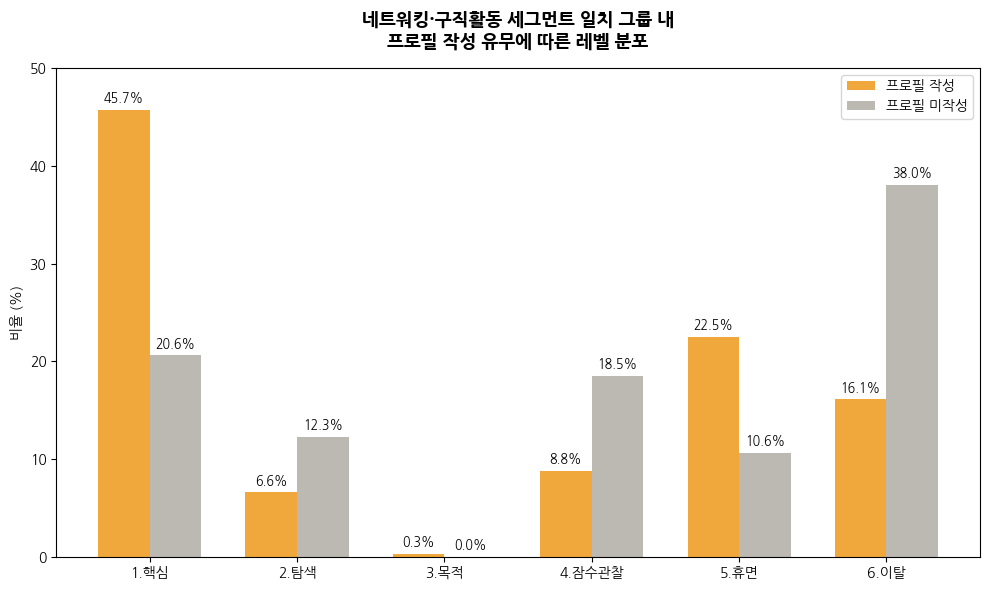


=== 일치 그룹 내 프로필 작성 유무에 따른 레벨 분포 (%) ===
           프로필 작성  프로필 미작성
net_level                 
1            45.7     20.6
2             6.6     12.3
3             0.3      0.0
4             8.8     18.5
5            22.5     10.6
6            16.1     38.0


In [17]:
# 두 세그먼트가 동일한 "단계"인 유저만 추출
def get_level(seg):
    return seg.split('.')[0]  # '1', '2', ... 추출

df_raw['net_level'] = df_raw['network_segment'].apply(get_level)
df_raw['job_level'] = df_raw['job_segment'].apply(get_level)

# 두 세그먼트 레벨이 일치하는 유저만
aligned = df_raw[df_raw['net_level'] == df_raw['job_level']].copy()
print(f"일치 유저 수: {len(aligned):,}명")
print(aligned['net_level'].value_counts().sort_index())

# early_behavior와 merge해서 프로필 작성 여부 비교
aligned_with_profile = aligned.merge(
    early_behavior[['user_uuid', 'has_profile']], on='user_uuid', how='left'
)

# 일치 그룹 내에서, 프로필 작성 여부에 따른 "레벨" 분포 비교
profile_yes_aligned = aligned_with_profile[aligned_with_profile['has_profile']]
profile_no_aligned  = aligned_with_profile[~aligned_with_profile['has_profile']]

level_compare = pd.DataFrame({
    '프로필 작성': profile_yes_aligned['net_level'].value_counts(normalize=True).mul(100).round(1),
    '프로필 미작성': profile_no_aligned['net_level'].value_counts(normalize=True).mul(100).round(1),
}).fillna(0).sort_index()

# =========================================================================
# 시각화
# =========================================================================

level_labels = {
    '1': '1.핵심', '2': '2.탐색', '3': '3.목적',
    '4': '4.잠수관찰', '5': '5.휴면', '6': '6.이탈'
}

fig, ax = plt.subplots(figsize=(10, 6))

x = level_compare.index.tolist()
x_pos = range(len(x))
width = 0.35

bars1 = ax.bar([p - width/2 for p in x_pos], level_compare['프로필 작성'],
               width=width, label='프로필 작성', color='#EF9F27', alpha=0.9)
bars2 = ax.bar([p + width/2 for p in x_pos], level_compare['프로필 미작성'],
               width=width, label='프로필 미작성', color='#B4B2A9', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels([level_labels[l] for l in x])
ax.set_ylabel('비율 (%)')
ax.set_ylim(0, 50)
ax.legend()
plt.title('네트워킹·구직활동 세그먼트 일치 그룹 내\n프로필 작성 유무에 따른 레벨 분포',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n=== 일치 그룹 내 프로필 작성 유무에 따른 레벨 분포 (%) ===")
print(level_compare)

=== 세그먼트별 프로필 항목 작성률 (%) — 일치 그룹 ===
   경력  학력  프로젝트  자격증  언어  전문분야  이력서  SNS  개요  이미지
1  52  22    28   18  20    52   36   29  11   29
2  24   6     6    4   5    15   16   10   4    7
3  65  19    38   27  23    65   35    8   4   27
4  20   2     4    3   2     7   13    8   3    5
5  57  25    29   22  23    50   39   29   7   25
6  19   3     4    3   3     7   12   10   3    4


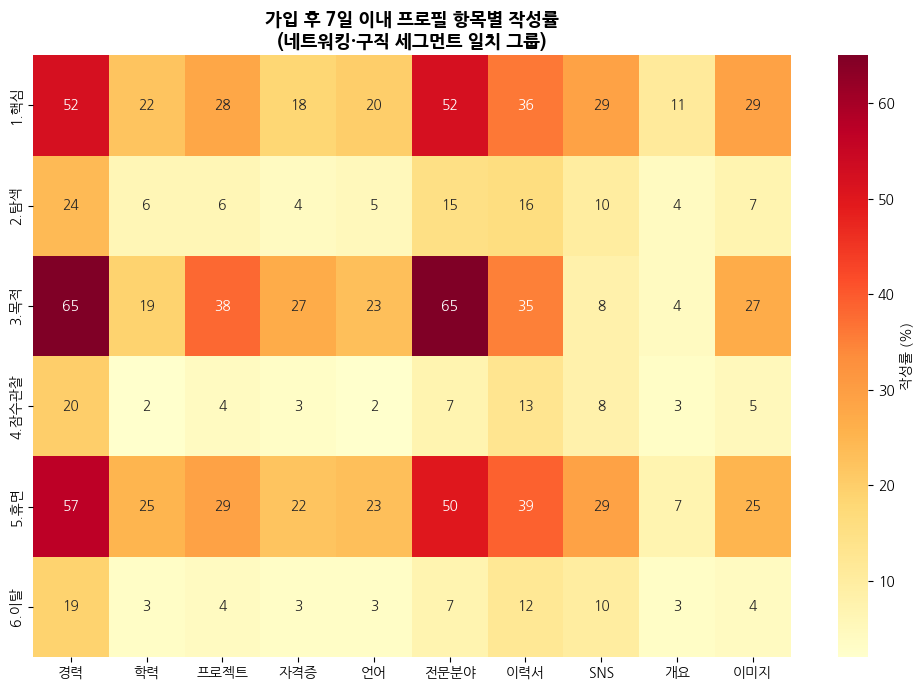

In [25]:
PROFILE_ITEM_URLS = {
    '경력':    {'api/users/id/career', 'api/users/id/career/template', 'api/users/id/career/id/form', 'api/users/id/career/id', 'api/users/id/experience/form'},
    '학력':    {'api/users/id/education', 'api/users/education/template'},
    '프로젝트': {'api/users/id/project', 'api/users/id/project/template', 'api/users/id/project/id/form', 'api/users/id/project/id', 'api/project/form_data/media', 'api/projects/id/media/add'},
    '자격증':  {'api/users/id/certification', 'api/users/id/certification/template'},
    '언어':    {'api/users/id/language', 'api/users/id/language/form'},
    '전문분야': {'api/users/id/specialty', 'api/users/id/specialty/template', 'api/users/id/specialty/id/vote'},
    '이력서':  {'api/users/id/resume/step1', 'api/users/id/resume/step2', '@user_id/resume', '@users/id/resume/step1', '@users/id/resume/step2'},
    'SNS':     {'api/users/id/sns', 'api/users/id/profile_image/facebook'},
    '개요':    {'api/users/id/overview'},
    '이미지':  {'api/users/id/image', 'api/users/id/profile_image'},
}

aligned_uuids = set(aligned['user_uuid'])
early_7d_aligned = early_7d[early_7d['user_uuid'].isin(aligned_uuids)]

level_labels_idx = {'1':'1.핵심','2':'2.탐색','3':'3.목적','4':'4.잠수관찰','5':'5.휴면','6':'6.이탈'}

def item_completion_rate(level, item_urls):
    seg_users = aligned[aligned['net_level'] == level]['user_uuid']
    n = len(seg_users)
    logs = early_7d_aligned[early_7d_aligned['user_uuid'].isin(seg_users)]
    users_with_item = logs[logs['url_normalized'].isin(item_urls)]['user_uuid'].nunique()
    return round(users_with_item / n * 100) if n > 0 else 0

heatmap = pd.DataFrame(index=sorted(aligned['net_level'].unique()), columns=PROFILE_ITEM_URLS.keys())
for level in heatmap.index:
    for item, urls in PROFILE_ITEM_URLS.items():
        heatmap.loc[level, item] = item_completion_rate(level, urls)

heatmap = heatmap.astype(int)

print("=== 세그먼트별 프로필 항목 작성률 (%) — 일치 그룹 ===")
print(heatmap)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            yticklabels=[level_labels_idx[i] for i in heatmap.index],
            cbar_kws={'label': '작성률 (%)'})
ax.set_title('가입 후 7일 이내 프로필 항목별 작성률\n(네트워킹·구직 세그먼트 일치 그룹)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

##전략 : 가입 당일 프로필 중 "경력/전문분야/이력서" 우선 작성 유도 온보딩

- 전제 : 모수가 충분히 큰 세그먼트(1.핵심 5,274명, 6.이탈 4,250명)만 비교 대상으로 한다. 3.목적형(26명) 등 소수 그룹은 노이즈 가능성이 높아 제외.
- 방식: 가입 절차 자체에 통합 — 가입 완료 직후 자동으로 "경력/전문분야/이력서" 작성 화면으로 연결. 또는 가입 후 1~2시간 내 미작성 시 즉시 인앱/푸시 리마인더(같은 날 안에 1회 발송이 핵심, 다음날부터는 효과 낮음)
- 채널: 인앱(가입 플로우 내 단계로 포함이 최우선) + 당일 한정 푸시 1회(이탈 방지용)
- 메시지 예시(가입 플로우 내):  "경력 · 전문분야 · 이력서, 이 3가지만 입력하면 맞춤 공고와 인맥을 추천받을 수 있어요" + 진행률 바(예: "2/3 완료, 1분만 더!")
- 기대 효과: 전체 가입자의 약 50%인 미작성자(약 10,477명) 중 일부가 당일 작성으로 전환되면, 이들의 핵심 세그먼트 진입 가능성이 현재 미작성자 그룹(20.6%) 대비 작성자 그룹(45.7%) 수준으로 높아질 잠재력. 이탈 세그먼트 비율도 38.0% → 16.1% 수준으로 낮아질 가능성.

- 한계 및 검증 필요사항: 이는 상관관계 기반 발견으로, 인과관계 확인을 위해 "가입 플로우 내 프로필 작성 유도 강화" 적용 그룹과 미적용 그룹의 A/B 테스트가 필요합니다. 다만 ① 효과 크기가 크고(2배 이상 차이), ② 일치 그룹으로 좁혀도 재현되며, ③ "가입 당일"이라는 구체적 실행 시점이 명확하다는 점에서, 우선 시도해볼 가치가 있는 전략으로 판단됩니다.

## 타겟 세그먼트 2 : 탐색 구직자


- 공고에 대한 정보는 적극적으로 보지만, 지원 행동으로 안이어지는 그룹임.
- 단순 구직 의지가 낮은게 아니라, 지원 단계에서 문제가 있는 것으로 가정함.

###가설 : 단순 구직 의지가 낮은게 아니라, 지원 단계에서 문제가 있음

- 지원 프로세스 중, 어느 단계에 이탈률이 높은지 진단 후, 해당 시점에 액션 추가
- 지원 프로세스는 공고 북마크 -> 지원 step1 -> 지원 step2 -> 지원 step3 -> 지원 step4 -> complete 순

In [18]:
# =========================================================================
# jobbookmark 데이터 로드
# =========================================================================

bookmark_df = pd.read_csv('/content/drive/MyDrive/jobbookmark.csv')
bookmark_df['cdate'] = pd.to_datetime(bookmark_df['cdate'], errors='coerce')

bookmark_22_23 = bookmark_df[
    (bookmark_df['cdate'] >= '2022-01-01') & (bookmark_df['cdate'] <= '2023-12-31')
]

In [19]:
# =========================================================================
# 시간순 퍼널 분석 (북마크 -> step1~4 -> 완료)
# =========================================================================

step_map = {
    'api/jobs/id/apply/step1': 1, 'jobs/id/apply/step1': 1,
    'api/jobs/id/apply/step2': 2, 'jobs/id/apply/step2': 2,
    'api/jobs/id/apply/step3': 3, 'jobs/id/apply/step3': 3,
    'api/jobs/id/apply/step4': 4, 'jobs/id/apply/step4': 4,
    'jobs/id/apply/complete': 5,
}

def max_consecutive_step(g):
    expected = 0
    reached = -1
    for s in g['step_num']:
        if s == expected:
            reached = expected
            expected += 1
        elif s == expected - 1:
            continue
        elif s > expected:
            break
    return reached

def run_funnel(target_users, label):
    apply_logs = df[df['user_uuid'].isin(target_users)].copy()
    apply_logs['step_num'] = apply_logs['url_normalized'].map(step_map)
    apply_logs = apply_logs.dropna(subset=['step_num'])
    apply_logs = apply_logs[['user_uuid', 'timestamp', 'step_num']].rename(columns={'timestamp': 'event_time'})

    bm_logs = bookmark_22_23[bookmark_22_23['user_uuid'].isin(target_users)].copy()
    bm_logs = bm_logs[['user_uuid', 'cdate']].rename(columns={'cdate': 'event_time'})
    bm_logs['step_num'] = 0

    all_events = pd.concat([bm_logs, apply_logs], ignore_index=True).sort_values(['user_uuid', 'event_time'])

    results = []
    for uid, g in all_events.groupby('user_uuid'):
        results.append({'user_uuid': uid, 'max_step': max_consecutive_step(g)})
    res_df = pd.DataFrame(results)

    all_target = pd.DataFrame({'user_uuid': target_users})
    res_df = all_target.merge(res_df, on='user_uuid', how='left')
    res_df['max_step'] = res_df['max_step'].fillna(-1)

    n = len(all_target)
    steps = ['북마크 도달', 'step1 도달', 'step2 도달', 'step3 도달', 'step4 도달', '완료']
    counts = [
        (res_df['max_step'] >= 0).sum(),
        (res_df['max_step'] >= 1).sum(),
        (res_df['max_step'] >= 2).sum(),
        (res_df['max_step'] >= 3).sum(),
        (res_df['max_step'] >= 4).sum(),
        (res_df['max_step'] >= 5).sum(),
    ]

    funnel_df = pd.DataFrame({'step': steps, 'user_count': counts})
    funnel_df['전체대비%'] = (funnel_df['user_count'] / n * 100).round(1)

    conv_rates = [None]
    drop_rates = [None]
    for i in range(1, len(counts)):
        prev, curr = counts[i-1], counts[i]
        conv = (curr / prev * 100) if prev > 0 else 0
        conv_rates.append(round(conv, 1))
        drop_rates.append(round(100 - conv, 1))

    funnel_df['전환율%'] = conv_rates
    funnel_df['이탈률%'] = drop_rates

    print(f"\n=== {label} (n={n}) ===")
    print(funnel_df.to_string(index=False))
    return res_df


target_explore = df_raw[df_raw['job_segment'] == '2. 탐색 구직자']['user_uuid']
target_active = df_raw[df_raw['job_segment'] == '1. 핵심 구직자']['user_uuid']

run_funnel(target_explore, "탐색 구직자")
run_funnel(target_active, "핵심 구직자")


=== 탐색 구직자 (n=3068) ===
    step  user_count  전체대비%  전환율%  이탈률%
  북마크 도달         756   24.6   NaN   NaN
step1 도달         374   12.2  49.5  50.5
step2 도달         249    8.1  66.6  33.4
step3 도달         145    4.7  58.2  41.8
step4 도달         111    3.6  76.6  23.4
      완료          43    1.4  38.7  61.3

=== 핵심 구직자 (n=6323) ===
    step  user_count  전체대비%  전환율%  이탈률%
  북마크 도달        2050   32.4   NaN   NaN
step1 도달        2009   31.8  98.0   2.0
step2 도달        1990   31.5  99.1   0.9
step3 도달        1455   23.0  73.1  26.9
step4 도달        1418   22.4  97.5   2.5
      완료         601    9.5  42.4  57.6


,user_uuid,max_step
0,000b55ad-5c86-438b-a5b0-9ea3a2917789,-1.0
1,004a89cc-d69b-4336-9905-4fd306e3ef80,-1.0
2,004fe85d-328f-408e-b64c-566227ecd8e8,-1.0
3,005d1d8c-2b25-4b4e-a5a3-a1f2a2efe7d2,-1.0
4,00605090-bd12-4978-884b-c74e093b40d0,-1.0
...,...,...
6318,ffd75368-f7ed-4eaf-9db9-0f76ef80af31,-1.0
6319,ffe429f9-200e-472d-9d72-2742727c8ea8,-1.0
6320,ffe6aee0-85cc-45e2-aa5e-129751dff08e,2.0
6321,ffeba6fd-76b6-41cc-8535-de3d9d86e079,-1.0



=== 탐색 구직자 (n=3068) ===
  step  user_count  전체대비%  전환율%  이탈률%
북마크 도달         756   24.6   NaN   NaN
 Step1         374   12.2  49.5  50.5
 Step2         249    8.1  66.6  33.4
 Step3         145    4.7  58.2  41.8
 Step4         111    3.6  76.6  23.4
 지원 완료          43    1.4  38.7  61.3

=== 핵심 구직자 (n=6323) ===
  step  user_count  전체대비%  전환율%  이탈률%
북마크 도달        2050   32.4   NaN   NaN
 Step1        2009   31.8  98.0   2.0
 Step2        1990   31.5  99.1   0.9
 Step3        1455   23.0  73.1  26.9
 Step4        1418   22.4  97.5   2.5
 지원 완료         601    9.5  42.4  57.6


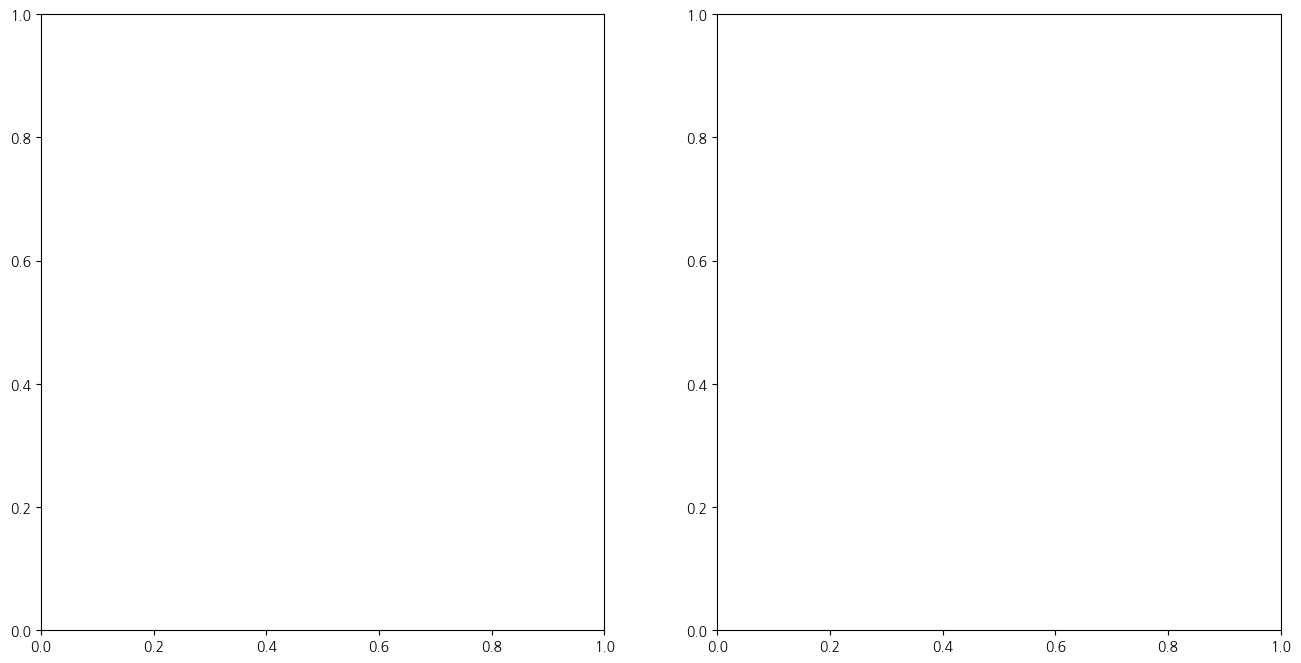

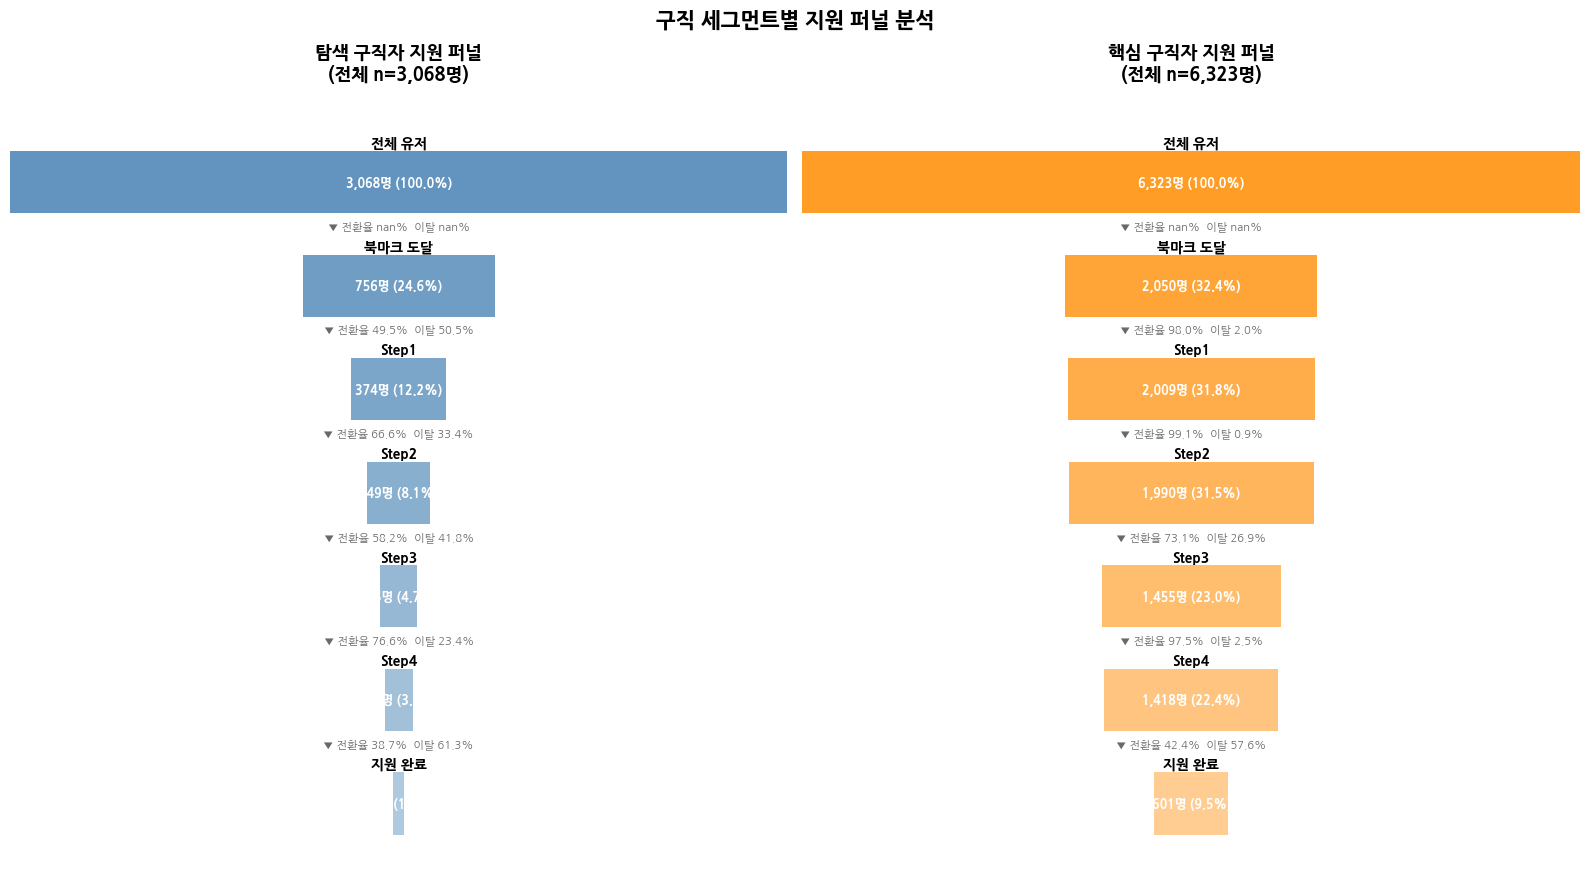

In [22]:
def run_funnel_with_viz(target_users, label):
    apply_logs = df[df['user_uuid'].isin(target_users)].copy()
    apply_logs['step_num'] = apply_logs['url_normalized'].map(step_map)
    apply_logs = apply_logs.dropna(subset=['step_num'])
    apply_logs = apply_logs[['user_uuid', 'timestamp', 'step_num']].rename(columns={'timestamp': 'event_time'})

    bm_logs = bookmark_22_23[bookmark_22_23['user_uuid'].isin(target_users)].copy()
    bm_logs = bm_logs[['user_uuid', 'cdate']].rename(columns={'cdate': 'event_time'})
    bm_logs['step_num'] = 0

    all_events = pd.concat([bm_logs, apply_logs], ignore_index=True).sort_values(['user_uuid', 'event_time'])

    results = []
    for uid, g in all_events.groupby('user_uuid'):
        results.append({'user_uuid': uid, 'max_step': max_consecutive_step(g)})
    res_df = pd.DataFrame(results)

    all_target = pd.DataFrame({'user_uuid': target_users})
    res_df = all_target.merge(res_df, on='user_uuid', how='left')
    res_df['max_step'] = res_df['max_step'].fillna(-1)

    n = len(all_target)
    steps = ['북마크 도달', 'Step1', 'Step2', 'Step3', 'Step4', '지원 완료']
    counts = [
        (res_df['max_step'] >= 0).sum(),
        (res_df['max_step'] >= 1).sum(),
        (res_df['max_step'] >= 2).sum(),
        (res_df['max_step'] >= 3).sum(),
        (res_df['max_step'] >= 4).sum(),
        (res_df['max_step'] >= 5).sum(),
    ]

    funnel_df = pd.DataFrame({'step': steps, 'user_count': counts})
    funnel_df['전체대비%'] = (funnel_df['user_count'] / n * 100).round(1)

    conv_rates = [None]
    drop_rates = [None]
    for i in range(1, len(counts)):
        prev, curr = counts[i-1], counts[i]
        conv = (curr / prev * 100) if prev > 0 else 0
        conv_rates.append(round(conv, 1))
        drop_rates.append(round(100 - conv, 1))

    funnel_df['전환율%'] = conv_rates
    funnel_df['이탈률%'] = drop_rates

    print(f"\n=== {label} (n={n}) ===")
    print(funnel_df.to_string(index=False))
    return funnel_df

# 퍼널 데이터 계산
target_explore = df_raw[df_raw['job_segment'] == '2. 탐색 구직자']['user_uuid']
target_active  = df_raw[df_raw['job_segment'] == '1. 핵심 구직자']['user_uuid']

funnel_explore = run_funnel_with_viz(target_explore, "탐색 구직자")
funnel_active  = run_funnel_with_viz(target_active,  "핵심 구직자")

# =========================================================================
# 시각화
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

def plot_funnel_shape(ax, funnel_df, label, color, n_total):
    # 전체 n을 맨 앞에 추가
    steps  = ['전체 유저'] + funnel_df['step'].tolist()
    counts = [n_total]    + funnel_df['user_count'].tolist()
    pcts   = [100.0]      + funnel_df['전체대비%'].tolist()
    convs  = [None]       + funnel_df['전환율%'].tolist()
    drops  = [None]       + funnel_df['이탈률%'].tolist()

    max_count = counts[0]

    for i, (step, count, pct, conv, drop) in enumerate(zip(steps, counts, pcts, convs, drops)):
        width = count / max_count
        left  = (1 - width) / 2

        ax.barh(y=-i, width=width, left=left,
                height=0.6, color=color, alpha=max(0.85 - i * 0.07, 0.3))

        # 스텝명
        ax.text(0.5, -i + 0.38, step, ha='center', va='center',
                fontsize=10, fontweight='bold')

        # 유저 수 + 비율
        ax.text(0.5, -i, f'{count:,}명 ({pct}%)',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

        # 전환율 / 이탈률 (첫 번째 제외)
        if i > 0 and conv is not None:
            ax.text(0.5, -i + 0.58,
                    f'▼ 전환율 {conv}%  이탈 {drop}%',
                    ha='center', va='center', fontsize=8, color='dimgray')

    ax.set_xlim(0, 1)
    ax.set_ylim(-len(steps) + 0.3, 0.8)
    ax.axis('off')
    ax.set_title(f'{label} 지원 퍼널\n(전체 n={n_total:,}명)', fontsize=13, fontweight='bold', pad=15)


n_explore = len(target_explore)
n_active  = len(target_active)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plot_funnel_shape(axes[0], funnel_explore, '탐색 구직자', 'steelblue',  n_explore)
plot_funnel_shape(axes[1], funnel_active,  '핵심 구직자', 'darkorange', n_active)

plt.suptitle('구직 세그먼트별 지원 퍼널 분석', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

###전략1 : 탐색 구직자 중, 북마크 후 지원하지 않는 유저 대상 "지원 시작 유도" (382명)

- 발송 시점 : 북마크 후 24~48시간 이내 1차 발송, 미반응 시 마감 임박(D-3 등) 시점에 2차 발송
- 채널 : 푸시 알림(즉시성, 행동 유도 효과적) + 이메일(공고 마감일 등 정보 포함, 푸시 미수신자 보완)
- 메세지 예시 : "북마크 하신 ㅇㅇ공고, 마감까지 3일 남았어요 - 지금 지원해보세요"
- 기대 효과 : 핵심 구직자의 step1 전환율인 98%를 기준으로 할 때, 탐색 구직자(현재 49.5%)가 이 격차의 일부만 좁혀도(예: 60~70%) 추가 step1 진입자 상당수 발생. 이는 퍼널 전체의 모수를 늘려 하위 단계(완료) 인원 증가로 이어짐.

###전략2 : 전체 구직자 대상 step4(최종 제출) 단계 개선

- 발송 시점 : step4 페이지 진입 후 일정 시간(30분~1시간) 내 미제출 시 리마인더 즉시 발송
- 채널: 인앱 알림/배너(이탈 시점이 사이트 내부이므로 가장 직접적)
- 메시지 예시 : "작성 중인 지원서가 있어요 — 마무리하고 제출하세요" (임시저장 기능이 있다면 "이어서 작성하기" 링크 포함)
- 기대 효과 : step4에서 complete 까지 이탈률이 핵심 구직자와 탐색 구직자 두 그룹 모두에서 가장 큰 손실 구간이므로, (61.3%/57.6%)은 두 그룹 모두에서 가장 큰 손실 구간. 이 단계는 모수 자체가 크므로(특히 핵심 구직자 1418명), 이탈률을 10%p만 낮춰도 완료 인원이 두 그룹 합산 약 150~250명 증가 가능

##타겟 세그먼트 2-2 : 탐색 구직자 중 핵심 네트워킹 (1029명)

- 사람과 회사에 대한 정보는 적극적으로 탐색하는데, 지원 행동으로 안이어지는 그룹임.
- 플랫폼 입장에서 수익화가 가장 안되는 케이스


###가설 : 추천 공고가 개인의 네트워킹 관심사(둘러본 회사/직무/사람)와 무관하게 모든 유저에게 동일하게 노출되어, "내가 관심 있는 영역"과 "추천받는 공고"가 단절되어 있음.

- 네트워킹에서 본 정보(관심 회사/직무/사람)와 구직 추천(공고)이 연결 안되었을 가능성. 네트워킹 활동 데이터를 구직 추천에 반영.

- 최근 둘러본 회사와 비슷한 직무 공고 추천

정성조사 제안:

- 유저 인터뷰 (이 세그먼트 내 5~10명): "최근 본 회사/사람"과 "추천 공고함에서 본 내용"이 본인에게 얼마나 관련 있게 느껴지는지, 추천 공고를 클릭하지 않는 이유 직접 질문
- 사용성 테스트(UT): 실제로 네트워킹 활동(회사 탐색, 팔로우 등)을 한 직후 추천 공고 화면을 보여주고, "이게 나와 관련 있다고 느끼는가"를 즉석에서 관찰
- 설문(정량 보완): 이 세그먼트 대상으로 "추천 공고가 본인 관심사와 얼마나 맞는지" 1~5점 평가 + 주관식("어떤 정보가 추천에 반영되면 좋을지")

UX 개선 방향(가설 검증 후):

- 추천 공고를 "전체 공통"이 아닌 "최근 둘러본 회사/직무 기반 개인화"로 전환
- 네트워킹 탭과 구직 탭 사이에 "당신이 관심 있을 만한 공고" 같은 연결 지점 신설 (예: 회사 페이지에서 "이 회사 채용 중" 배너)

## 타겟 세그먼트 3 : 탐색 네트워킹

- 사람/회사 정보를 충분히 보고 있지만, 연결 행동으로 전환되지는 않음. 심리적 진입장벽이 원인일 수 있음

###전략제안

아이디어 1: 커피챗 제안 기능
- 특정 프로필을 N회 이상 조회한 유저에게 "이 분께 커피챗 제안해보기" 버튼 노출. 정중한 템플릿 메시지 제공으로 작성 부담 낮춤.

아이디어 2: 추천인/멘토 매칭 제도
- 같은 직무·산업 "선배" 유저를 매칭해, 신규/탐색형 유저가 부담 없이 질문할 수 있는 1:1 채널 제공. 멘토 측에는 활동 포인트/뱃지 등 인센티브 부여.

아이디어 3: 업계 종사자 추천 알고리즘
- 탐색 중인 회사/직무와 연결된 "현직자"를 자동 추천하고, "이 분은 회원님과 같은 분야에 관심이 있어요" 같은 약한 연결고리 제시 → 팔로우/연결 행동의 명분 제공.

기대 효과: passive(탐색) → active(연결) 전환의 심리적 장벽을 낮춰, 탐색형(2번) 그룹의 active_network_score 상승 → 핵심(1번)으로의 전환 유도.

한계: 이 전략들은 데이터로 직접 검증된 게 아니라, "탐색은 하는데 행동은 안 한다"는 패턴에 대한 업계 일반적 솔루션 제안입니다. 도입 후 효과는 A/B 테스트로 확인이 필요합니다.

#태블로

In [25]:
import os
os.makedirs('/content/drive/MyDrive/tableau_export', exist_ok=True)

# ① 월별 MAU
monthly_users[['year_month_str', 'unique_users']].rename(
    columns={'year_month_str': '연월', 'unique_users': 'MAU'}
).to_csv('/content/drive/MyDrive/tableau_export/01_mau.csv', index=False)

# ② 월별 신규 유저수
new_users_monthly[['cohort_month_str', 'new_users']].rename(
    columns={'cohort_month_str': '연월', 'new_users': '신규유저수'}
).to_csv('/content/drive/MyDrive/tableau_export/02_new_users.csv', index=False)

# ③ 요일/시간대별 접속 패턴
heatmap_reset = heatmap_data.reset_index()
heatmap_reset.columns = ['요일'] + [str(int(c)) for c in heatmap_reset.columns[1:]]
heatmap_long = heatmap_reset.melt(
    id_vars='요일', var_name='시간대', value_name='유니크유저수'
)
heatmap_long.to_csv('/content/drive/MyDrive/tableau_export/03_heatmap.csv', index=False)

# ④ 세그먼트 분포 (네트워킹)
seg_dist = df_raw.groupby('network_segment')['user_uuid'].nunique().reset_index()
seg_dist.columns = ['세그먼트', '유저수']
seg_dist['비율'] = (seg_dist['유저수'] / seg_dist['유저수'].sum() * 100).round(1)
seg_dist.to_csv('/content/drive/MyDrive/tableau_export/04_network_segment_dist.csv', index=False)

# ⑤ 세그먼트 분포 (구직활동)
job_dist = df_raw.groupby('job_segment')['user_uuid'].nunique().reset_index()
job_dist.columns = ['세그먼트', '유저수']
job_dist['비율'] = (job_dist['유저수'] / job_dist['유저수'].sum() * 100).round(1)
job_dist.to_csv('/content/drive/MyDrive/tableau_export/05_job_segment_dist.csv', index=False)

# ⑥ 세그먼트별 월별 잔류율 (네트워킹) - long format
net_ret_long = net_ret_df.reset_index().melt(
    id_vars='months_since_join', var_name='세그먼트', value_name='잔류율'
).rename(columns={'months_since_join': '경과월'})
net_ret_long.to_csv('/content/drive/MyDrive/tableau_export/06_net_retention.csv', index=False)

# ⑦ 세그먼트별 월별 잔류율 (구직활동) - long format
job_ret_long = job_ret_df.reset_index().melt(
    id_vars='months_since_join', var_name='세그먼트', value_name='잔류율'
).rename(columns={'months_since_join': '경과월'})
job_ret_long.to_csv('/content/drive/MyDrive/tableau_export/07_job_retention.csv', index=False)

# ⑧⑨ 퍼널 분석 합본
funnel_explore['세그먼트'] = '탐색 구직자'
funnel_active['세그먼트']  = '핵심 구직자'
funnel_combined = pd.concat([funnel_explore, funnel_active], ignore_index=True)
funnel_combined.to_csv('/content/drive/MyDrive/tableau_export/08_funnel_combined.csv', index=False)

print("✅ 전체 CSV 저장 완료!")
print("저장 위치: /content/drive/MyDrive/tableau_export/")

✅ 전체 CSV 저장 완료!
저장 위치: /content/drive/MyDrive/tableau_export/


#참고

#지원(applicaton 테이블)

In [9]:
# =========================================================================
# application 테이블 로드
# =========================================================================

application = pd.read_csv(
    '/content/drive/MyDrive/application.csv',
    on_bad_lines='skip', low_memory=False
)

print(f"지원 데이터: {len(application):,}행")
print(f"지원 유저 수: {application['user_uuid'].nunique():,}명")
print(f"\n컬럼: {application.columns.tolist()}")
print(f"\n날짜 범위:")
application['cdate'] = pd.to_datetime(application['cdate'], errors='coerce')
print(f"최솟값: {application['cdate'].min()}")
print(f"최댓값: {application['cdate'].max()}")
print(f"\n결측치:")
print(application.isnull().sum())
print(f"\n샘플:")
display(application.head())

지원 데이터: 340,730행
지원 유저 수: 36,732명

컬럼: ['cdate', 'company_uuid', 'job_uuid', 'user_uuid', 'application_uuid']

날짜 범위:
최솟값: 2015-02-24 10:22:28
최댓값: 2023-12-31 14:45:05

결측치:
cdate               0
company_uuid        0
job_uuid            0
user_uuid           0
application_uuid    0
dtype: int64

샘플:


,cdate,company_uuid,job_uuid,user_uuid,application_uuid
0,2017-02-25 23:45:01,de4b3596-b4ab-47cd-b8ea-6f9e14170064,459e461d-a571-4ed3-8751-8f4cb5b9ff37,b0329bd7-fc45-4e83-993a-b73bd9d3549c,59c42363-f764-4cbd-aafd-20eb663ea5d7
1,2020-11-23 14:46:07,f6156b12-d4d7-469f-84be-31799c765211,e5ed4f4a-08aa-4f2d-9042-1e9bbd36803f,b0329bd7-fc45-4e83-993a-b73bd9d3549c,425db0e8-87f8-4b4d-8248-7f24c31d49d3
2,2017-10-28 22:30:11,2ed05b18-c735-474a-9faa-02095b25729a,0f636d7a-53f7-485e-8a08-33253ddab380,b0329bd7-fc45-4e83-993a-b73bd9d3549c,be4d9e85-dc53-4e70-90af-64d2d6b117d2
3,2017-07-03 17:40:05,3d6730ee-b869-47b7-90c6-1e074e4eb15b,3cade56a-6354-411a-82a6-f2c7774539c1,b0329bd7-fc45-4e83-993a-b73bd9d3549c,d43879d1-c424-4192-9eae-4537fa6687cb
4,2017-02-10 10:53:39,de4b3596-b4ab-47cd-b8ea-6f9e14170064,459e461d-a571-4ed3-8751-8f4cb5b9ff37,a7593a15-b93e-4bc3-91bf-e4074c931d33,61873fd7-f075-44c0-90fe-f6521226550d


In [10]:
# 2022-01-01 이후 데이터만 필터링
application = application[
    application['cdate'] >= '2022-01-01'
].copy()

print(f"필터링 후 지원 데이터: {len(application):,}행")
print(f"필터링 후 지원 유저 수: {application['user_uuid'].nunique():,}명")
print(f"\n날짜 범위:")
print(f"최솟값: {application['cdate'].min()}")
print(f"최댓값: {application['cdate'].max()}")

필터링 후 지원 데이터: 92,514행
필터링 후 지원 유저 수: 10,285명

날짜 범위:
최솟값: 2022-01-01 01:32:27
최댓값: 2023-12-31 14:45:05


전체 유저: 21,221명

=== 적극적 네트워킹 경험 유무별 지원 현황 ===

적극적 네트워킹 경험자 (17,421명)
  지원 경험률: 58.6% (10,214명)
  1인당 평균 지원: 4.94건

적극적 네트워킹 미경험자 (3,800명)
  지원 경험률: 0.9% (34명)
  1인당 평균 지원: 0.05건

=== 전체 네트워킹 경험 유무별 지원 현황 ===

전체 네트워킹 경험자 (20,659명)
  지원 경험률: 49.6% (10,241명)
  1인당 평균 지원: 4.18건

전체 네트워킹 미경험자 (562명)
  지원 경험률: 1.2% (7명)
  1인당 평균 지원: 0.02건

=== 통계 검정 (적극적 네트워킹 기준) ===
z-statistic: 64.5317
p-value: 0.0000e+00
통계적 유의성: 있음 (p < 0.05)


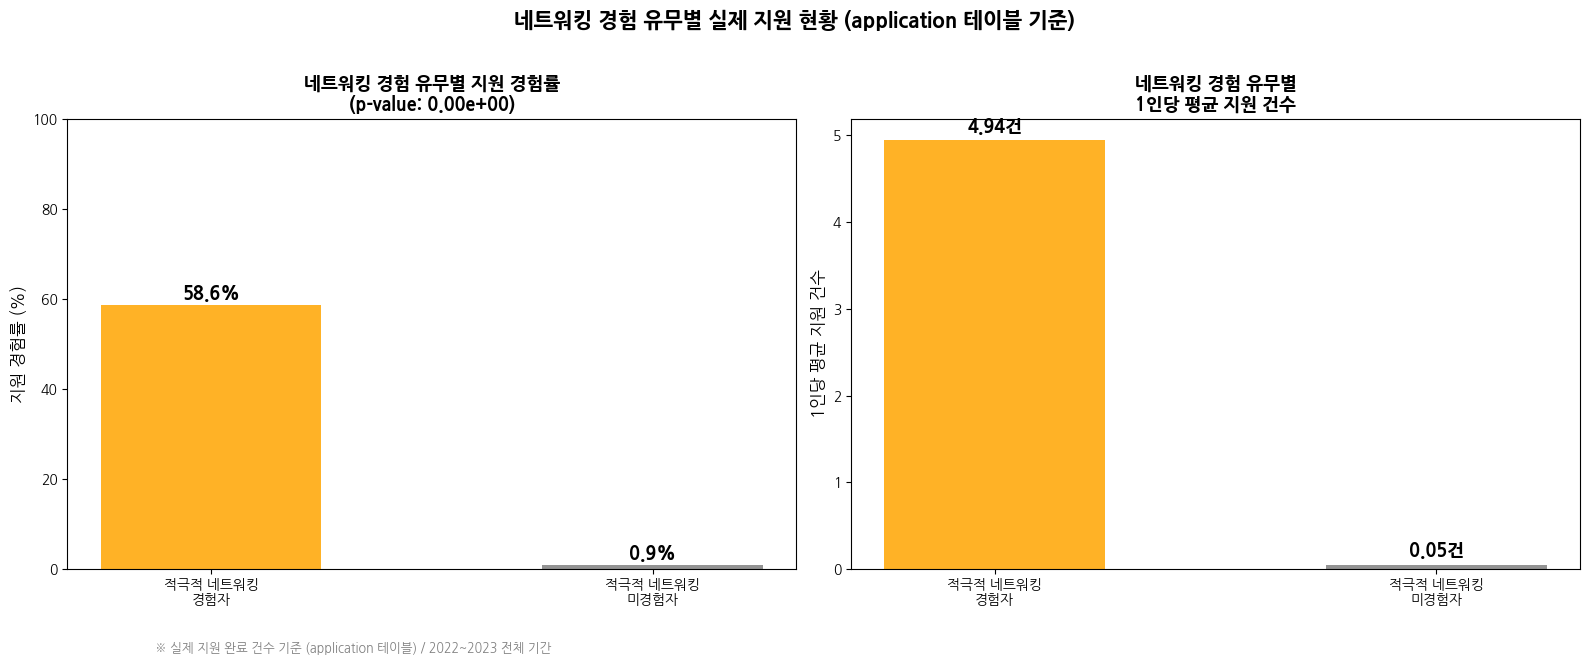

In [9]:
# =========================================================================
# 네트워킹 경험 유무별 실제 지원 건수 비교
# =========================================================================

# 유저별 네트워킹 경험 여부
network_experience = df_raw[['user_uuid', 'active_network_raw', 'passive_network_raw']].copy()
network_experience['has_active_network'] = network_experience['active_network_raw'] > 0
network_experience['has_any_network']    = (
    network_experience['active_network_raw'] + network_experience['passive_network_raw']
) > 0

# 유저별 실제 지원 건수
user_apply = (
    application.groupby('user_uuid')
    .size()
    .reset_index()
)
user_apply.columns = ['user_uuid', 'apply_count']

# 전체 유저 기준으로 병합 (지원 안 한 유저는 0)
result = network_experience.merge(user_apply, on='user_uuid', how='left')
result['apply_count'] = result['apply_count'].fillna(0)

# 지원 경험 여부
result['has_applied'] = result['apply_count'] > 0

print(f"전체 유저: {len(result):,}명")
print(f"\n=== 적극적 네트워킹 경험 유무별 지원 현황 ===")
for val, label in [(True, '경험자'), (False, '미경험자')]:
    group = result[result['has_active_network'] == val]
    applied = group['has_applied'].sum()
    total   = len(group)
    avg     = group['apply_count'].mean()
    print(f"\n적극적 네트워킹 {label} ({total:,}명)")
    print(f"  지원 경험률: {applied/total*100:.1f}% ({applied:,}명)")
    print(f"  1인당 평균 지원: {avg:.2f}건")

print(f"\n=== 전체 네트워킹 경험 유무별 지원 현황 ===")
for val, label in [(True, '경험자'), (False, '미경험자')]:
    group = result[result['has_any_network'] == val]
    applied = group['has_applied'].sum()
    total   = len(group)
    avg     = group['apply_count'].mean()
    print(f"\n전체 네트워킹 {label} ({total:,}명)")
    print(f"  지원 경험률: {applied/total*100:.1f}% ({applied:,}명)")
    print(f"  1인당 평균 지원: {avg:.2f}건")

# 통계 검정
from statsmodels.stats.proportion import proportions_ztest

# 적극적 네트워킹 기준
net_yes = result[result['has_active_network'] == True]['has_applied']
net_no  = result[result['has_active_network'] == False]['has_applied']

count = [net_yes.sum(), net_no.sum()]
nobs  = [len(net_yes), len(net_no)]
z_stat, p_value = proportions_ztest(count, nobs)

print(f"\n=== 통계 검정 (적극적 네트워킹 기준) ===")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"통계적 유의성: {'있음 (p < 0.05)' if p_value < 0.05 else '없음'}")

# =========================================================================
# 시각화
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 지원 경험률 비교
categories = ['적극적 네트워킹\n경험자', '적극적 네트워킹\n미경험자']
rates = [
    result[result['has_active_network'] == True]['has_applied'].mean() * 100,
    result[result['has_active_network'] == False]['has_applied'].mean() * 100
]

bars = axes[0].bar(categories, rates,
                   color=['orange', 'gray'], alpha=0.85, width=0.5)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%',
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=13)
axes[0].set_ylabel('지원 경험률 (%)', fontsize=12)
axes[0].set_ylim(0, 100)
axes[0].set_title(f'네트워킹 경험 유무별 지원 경험률\n(p-value: {p_value:.2e})',
                   fontsize=13, fontweight='bold')

# 1인당 평균 지원 건수 비교
avg_counts = [
    result[result['has_active_network'] == True]['apply_count'].mean(),
    result[result['has_active_network'] == False]['apply_count'].mean()
]

bars2 = axes[1].bar(categories, avg_counts,
                    color=['orange', 'gray'], alpha=0.85, width=0.5)
for bar, val in zip(bars2, avg_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}건',
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=13)
axes[1].set_ylabel('1인당 평균 지원 건수', fontsize=12)
axes[1].set_title('네트워킹 경험 유무별\n1인당 평균 지원 건수',
                   fontsize=13, fontweight='bold')

plt.suptitle('네트워킹 경험 유무별 실제 지원 현황 (application 테이블 기준)',
             fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.1, -0.05,
    "※ 실제 지원 완료 건수 기준 (application 테이블) / 2022~2023 전체 기간",
    fontsize=9, color='gray')
plt.tight_layout()
plt.show()

In [12]:
# 유저별 실제 지원 건수
user_apply = (
    application.groupby('user_uuid')
    .size()
    .reset_index()
)
user_apply.columns = ['user_uuid', 'apply_count']

print(f"지원 경험 유저: {len(user_apply):,}명")
print(f"1인당 평균 지원: {user_apply['apply_count'].mean():.2f}건")

지원 경험 유저: 10,285명
1인당 평균 지원: 9.00건


=== 적극적 네트워커 vs 비적극적 네트워커 지원 현황 ===

적극적 네트워커 (9,615명)
  지원 경험률: 69.2% (6,649명)
  1인당 평균 지원: 7.23건

비적극적 네트워커 (11,606명)
  지원 경험률: 31.0% (3,599명)
  1인당 평균 지원: 1.44건

=== 통계 검정 ===
z-statistic: 55.3511
p-value: 0.0000e+00
통계적 유의성: 있음 (p < 0.05)


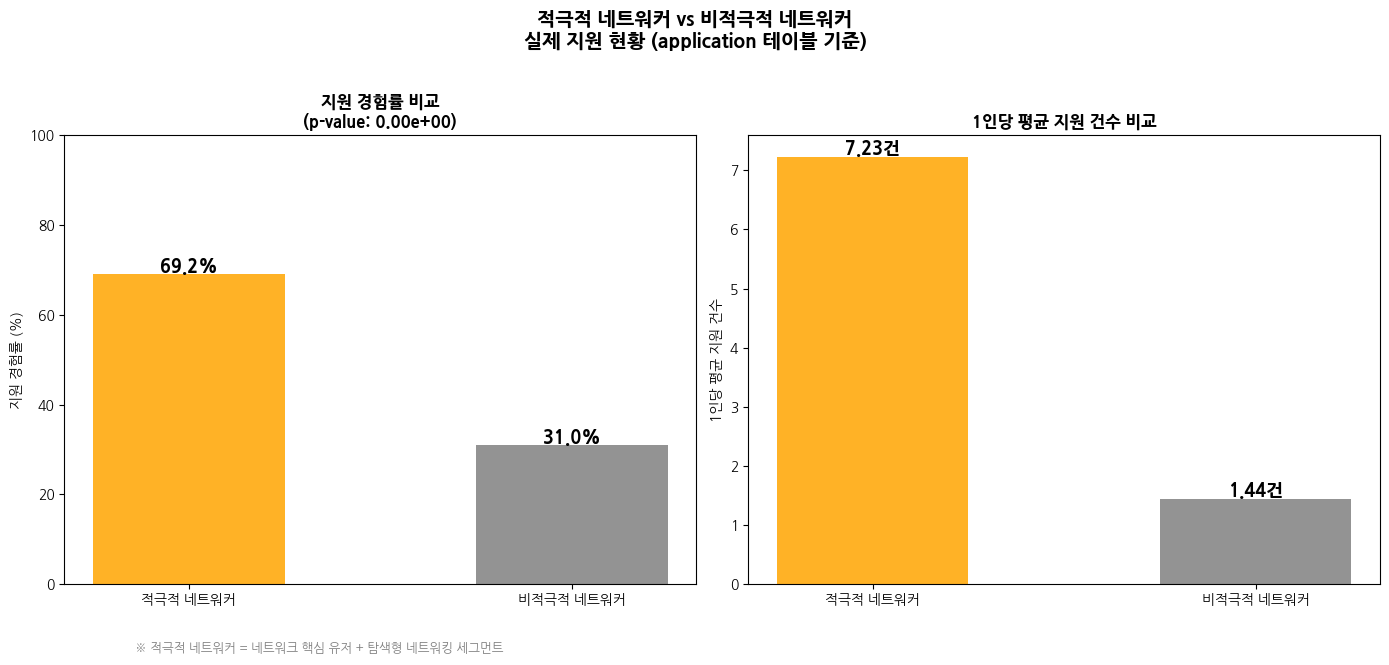

In [13]:
# =========================================================================
# 적극적 네트워커 vs 비적극적 네트워커 지원 현황
# =========================================================================

# 세그먼트 기준 분류
active_networkers = [
    '1. 네트워크 핵심 유저 (The Connector)',
    '2. 탐색형 네트워킹 (The Observer)',
]

df_raw['is_active_networker'] = df_raw['network_segment'].isin(active_networkers)

# application 병합
result2 = df_raw[['user_uuid', 'is_active_networker']].merge(
    user_apply, on='user_uuid', how='left'
)
result2['apply_count'] = result2['apply_count'].fillna(0)
result2['has_applied'] = result2['apply_count'] > 0

print("=== 적극적 네트워커 vs 비적극적 네트워커 지원 현황 ===")
for val, label in [(True, '적극적 네트워커'), (False, '비적극적 네트워커')]:
    group   = result2[result2['is_active_networker'] == val]
    applied = group['has_applied'].sum()
    total   = len(group)
    avg     = group['apply_count'].mean()
    print(f"\n{label} ({total:,}명)")
    print(f"  지원 경험률: {applied/total*100:.1f}% ({applied:,}명)")
    print(f"  1인당 평균 지원: {avg:.2f}건")

# 통계 검정
from statsmodels.stats.proportion import proportions_ztest

yes = result2[result2['is_active_networker'] == True]['has_applied']
no  = result2[result2['is_active_networker'] == False]['has_applied']

count = [yes.sum(), no.sum()]
nobs  = [len(yes), len(no)]
z_stat, p_value = proportions_ztest(count, nobs)

print(f"\n=== 통계 검정 ===")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"통계적 유의성: {'있음 (p < 0.05)' if p_value < 0.05 else '없음'}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = ['적극적 네트워커', '비적극적 네트워커']
rates = [
    result2[result2['is_active_networker'] == True]['has_applied'].mean() * 100,
    result2[result2['is_active_networker'] == False]['has_applied'].mean() * 100
]
avgs = [
    result2[result2['is_active_networker'] == True]['apply_count'].mean(),
    result2[result2['is_active_networker'] == False]['apply_count'].mean()
]

bars = axes[0].bar(categories, rates,
                   color=['orange', 'gray'], alpha=0.85, width=0.5)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylabel('지원 경험률 (%)')
axes[0].set_ylim(0, 100)
axes[0].set_title(f'지원 경험률 비교\n(p-value: {p_value:.2e})',
                   fontsize=12, fontweight='bold')

bars2 = axes[1].bar(categories, avgs,
                    color=['orange', 'gray'], alpha=0.85, width=0.5)
for bar, val in zip(bars2, avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}건',
                 ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylabel('1인당 평균 지원 건수')
axes[1].set_title('1인당 평균 지원 건수 비교',
                   fontsize=12, fontweight='bold')

plt.suptitle('적극적 네트워커 vs 비적극적 네트워커\n실제 지원 현황 (application 테이블 기준)',
             fontsize=14, fontweight='bold', y=1.02)
plt.figtext(0.1, -0.05,
    "※ 적극적 네트워커 = 네트워크 핵심 유저 + 탐색형 네트워킹 세그먼트",
    fontsize=9, color='gray')
plt.tight_layout()
plt.show()

#공고(job 테이블)

In [14]:
# =========================================================================
# job 테이블 로드 및 전처리
# =========================================================================

job = pd.read_csv(
    '/content/drive/MyDrive/공고_clean.csv',
    on_bad_lines='skip', low_memory=False
)

print(f"공고 데이터: {len(job):,}행")
print(f"\n컬럼: {job.columns.tolist()}")
print(f"\n샘플:")
display(job.head())
print(f"\n결측치:")
print(job.isnull().sum())

공고 데이터: 139,764행

컬럼: ['cdate', 'mdate', 'job_field', 'career_type_string', 'start_date', 'end_date', 'allow_remote', 'can_show_salary', 'job_uuid', 'company_uuid']

샘플:


,cdate,mdate,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary,job_uuid,company_uuid
0,2020-11-25 10:32:10,2020-11-25 10:32:10,SW 개발,"신입,경력,인턴",2020-11-25,2020-11-25,1,0,764292b0-53f8-4f14-ac83-6eafc7a6a18d,daa34559-fc42-47f6-b5c6-cc6171404f37
1,2020-12-03 16:24:16,2020-12-03 16:24:16,HW 개발,인턴,2020-12-03,2020-12-04,1,0,b2b598d6-9ca3-4eb4-ac9c-bb57a6dad2ad,daa34559-fc42-47f6-b5c6-cc6171404f37
2,2019-06-13 08:47:25,2019-06-13 08:47:25,디자인,"신입,경력,인턴",2019-06-13,2019-06-21,0,0,017f4d7d-91a9-4ef7-9dd7-afabf7cbd26d,d4e7e647-8f85-4e7f-8609-7173cc240e18
3,2019-06-14 01:34:45,2019-07-02 00:28:35,마케팅,경력,2019-06-14,2019-07-15,0,0,41707ef1-f733-4f58-bb29-0b2e6175cf5e,d4e7e647-8f85-4e7f-8609-7173cc240e18
4,2019-07-02 00:28:58,2019-07-16 13:03:08,운영,"신입,경력",2019-07-02,2019-08-31,0,0,d0aa0eef-65d2-4e00-8177-968a2dc52009,d4e7e647-8f85-4e7f-8609-7173cc240e18



결측치:
cdate                 0
mdate                 0
job_field             0
career_type_string    0
start_date            0
end_date              0
allow_remote          0
can_show_salary       0
job_uuid              0
company_uuid          0
dtype: int64


JOIN 결과: 92,514행
매칭된 유저 수: 10,285명

=== 기본 통계 ===
job_field 결측: 3,401
allow_remote 결측: 3,401
can_show_salary 결측: 3,401

=== 직군별 지원 건수 TOP 10 ===
           count     %
job_field             
SW 개발      62816  70.5
기획/PM       6948   7.8
디자인         6545   7.3
마케팅         4993   5.6
비즈니스        2514   2.8
운영          2504   2.8
경영지원        2286   2.6
게임 개발        218   0.2
HW 개발        156   0.2
투자           133   0.1

=== 연봉공개 여부별 지원 건수 ===
                 count     %
can_show_salary             
0.0              57367  64.4
1.0              31746  35.6

=== 원격근무 여부별 지원 건수 ===
              count     %
allow_remote             
0.0           69943  78.5
1.0           19170  21.5

=== 경력 형태별 지원 건수 ===
                    count     %
career_type_string             
신입,경력               36705  41.2
경력                  36170  40.6
신입,경력,인턴             9258  10.4
신입                   3215   3.6
인턴                   1967   2.2
신입,인턴                1724   1.9
경력,인턴                  74   0.1



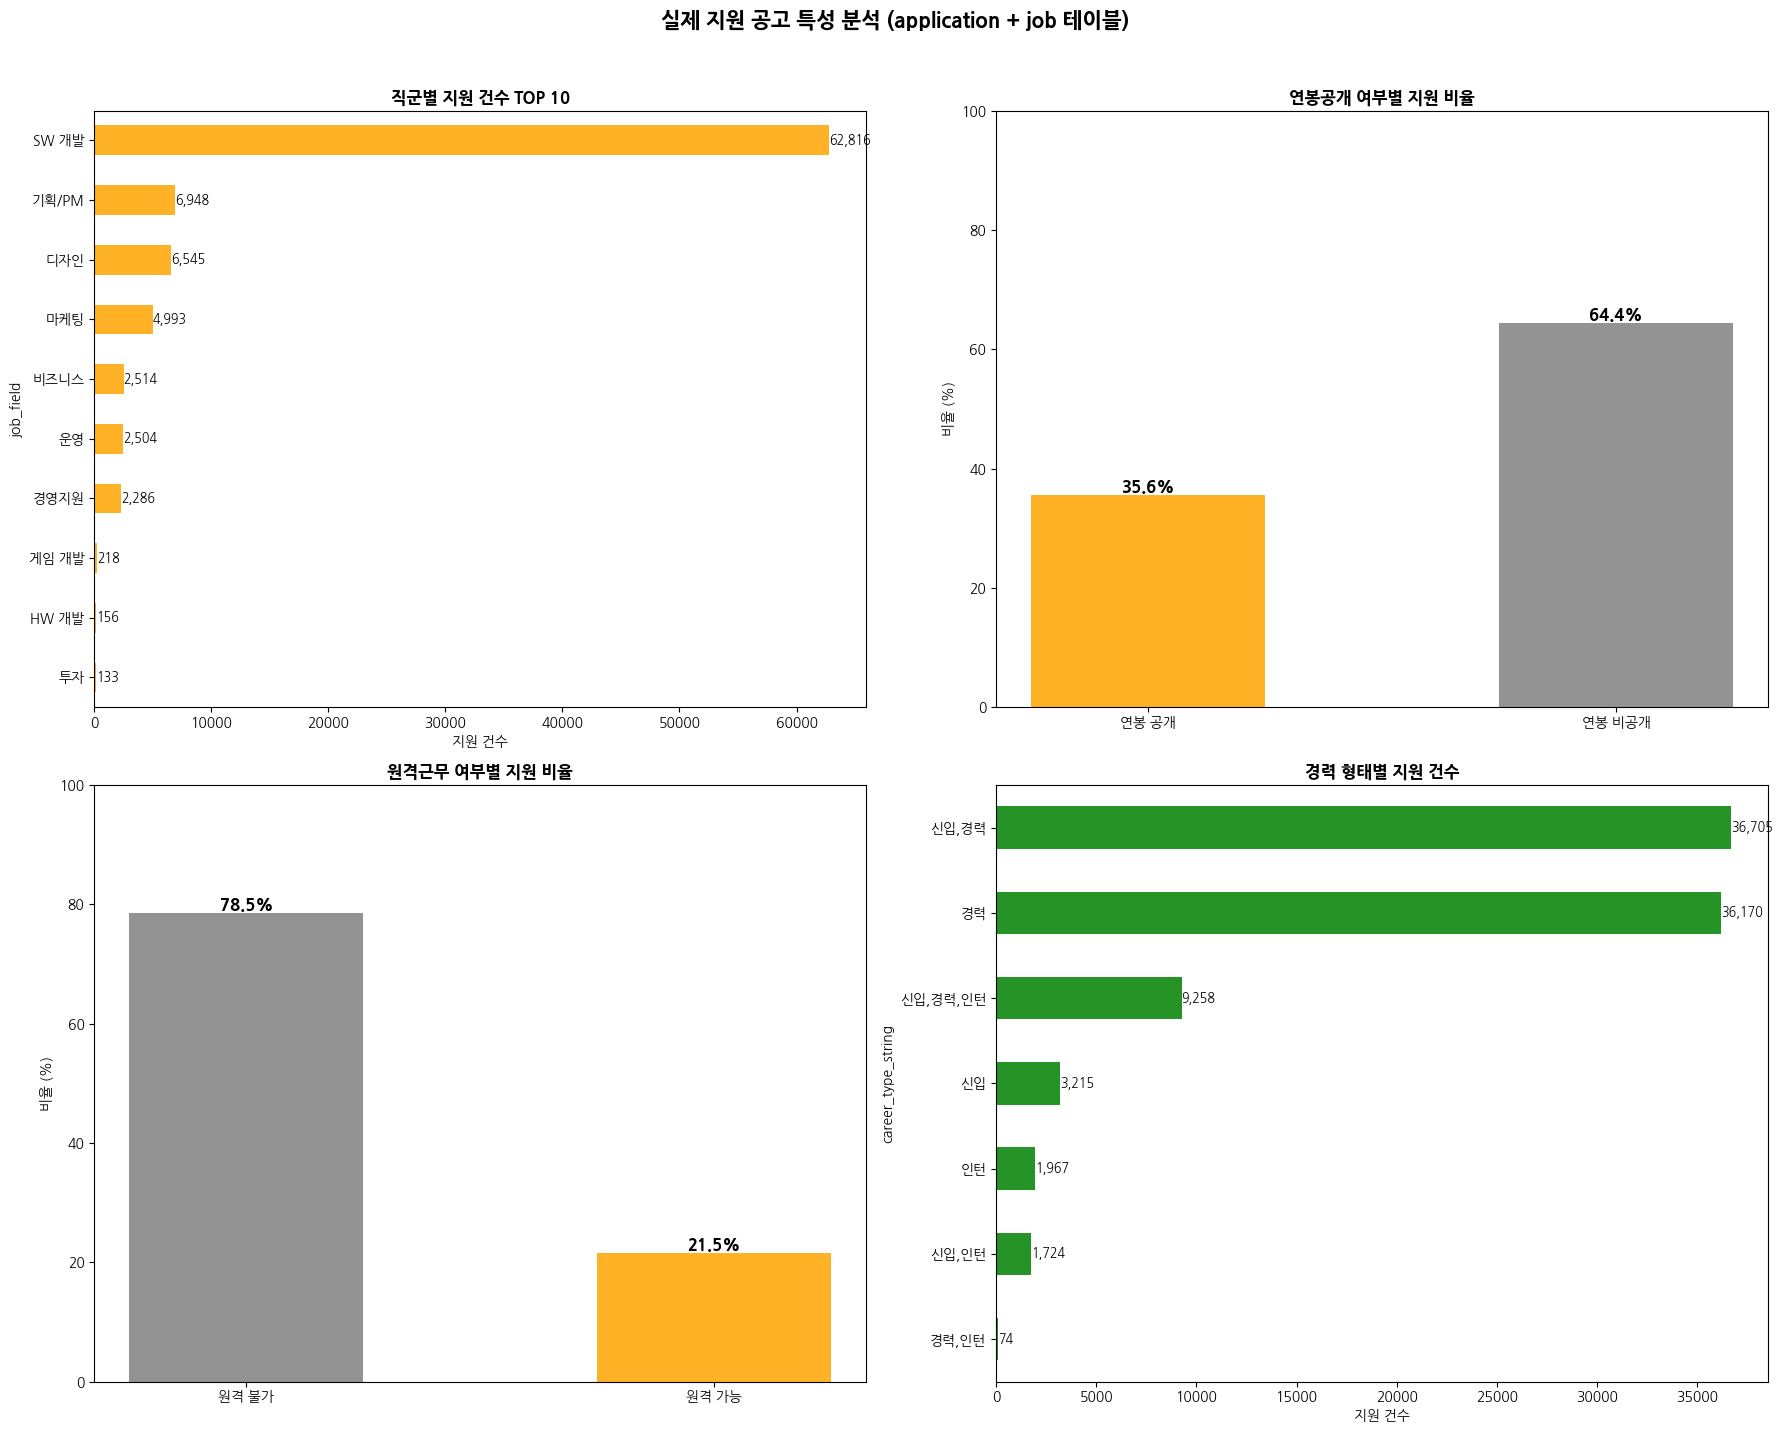

In [15]:
# =========================================================================
# application + job 테이블 JOIN
# =========================================================================

app_job = application.merge(
    job[['job_uuid', 'job_field', 'career_type_string',
         'allow_remote', 'can_show_salary', 'start_date', 'end_date']],
    on='job_uuid', how='left'
)

# 유저 세그먼트 정보 추가
app_job = app_job.merge(
    df_raw[['user_uuid', 'network_segment', 'job_segment']],
    on='user_uuid', how='left'
)

print(f"JOIN 결과: {len(app_job):,}행")
print(f"매칭된 유저 수: {app_job['user_uuid'].nunique():,}명")
print(f"\n=== 기본 통계 ===")
print(f"job_field 결측: {app_job['job_field'].isna().sum():,}")
print(f"allow_remote 결측: {app_job['allow_remote'].isna().sum():,}")
print(f"can_show_salary 결측: {app_job['can_show_salary'].isna().sum():,}")

# =========================================================================
# 분석 1: 직군별 지원 현황
# =========================================================================

print("\n=== 직군별 지원 건수 TOP 10 ===")
job_field_counts = app_job['job_field'].value_counts().head(10)
job_field_pct    = app_job['job_field'].value_counts(normalize=True).mul(100).round(1).head(10)
print(pd.DataFrame({'count': job_field_counts, '%': job_field_pct}))

# =========================================================================
# 분석 2: 연봉공개 여부별 지원 현황
# =========================================================================

print("\n=== 연봉공개 여부별 지원 건수 ===")
salary_counts = app_job['can_show_salary'].value_counts()
salary_pct    = app_job['can_show_salary'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'count': salary_counts, '%': salary_pct}))

# =========================================================================
# 분석 3: 원격근무 여부별 지원 현황
# =========================================================================

print("\n=== 원격근무 여부별 지원 건수 ===")
remote_counts = app_job['allow_remote'].value_counts()
remote_pct    = app_job['allow_remote'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'count': remote_counts, '%': remote_pct}))

# =========================================================================
# 분석 4: 경력 형태별 지원 현황
# =========================================================================

print("\n=== 경력 형태별 지원 건수 ===")
career_counts = app_job['career_type_string'].value_counts().head(10)
career_pct    = app_job['career_type_string'].value_counts(normalize=True).mul(100).round(1).head(10)
print(pd.DataFrame({'count': career_counts, '%': career_pct}))

# =========================================================================
# 분석 5: 네트워킹 세그먼트별 직군 선호도
# =========================================================================

print("\n=== 네트워킹 세그먼트별 직군 TOP 3 ===")
target_segments = [
    '1. 네트워크 핵심 유저 (The Connector)',
    '2. 탐색형 네트워킹 (The Observer)',
    '4. 관망형 유저 (The Lurker)',
]
for seg in target_segments:
    group = app_job[app_job['network_segment'] == seg]
    top3  = group['job_field'].value_counts().head(3)
    print(f"\n{seg.split('(')[0].strip()}")
    print(top3)

# =========================================================================
# 시각화
# =========================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 직군별 지원 건수
job_field_counts.sort_values().plot(
    kind='barh', ax=axes[0][0], color='orange', alpha=0.85
)
for i, val in enumerate(job_field_counts.sort_values()):
    axes[0][0].text(val + 10, i, f'{val:,}', va='center', fontsize=9)
axes[0][0].set_title('직군별 지원 건수 TOP 10', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('지원 건수')

# 연봉공개 여부별
axes[0][1].bar(
    ['연봉 공개', '연봉 비공개'],
    [salary_pct.get(1, 0), salary_pct.get(0, 0)],
    color=['orange', 'gray'], alpha=0.85, width=0.5
)
for i, (label, val) in enumerate(zip(
    ['연봉 공개', '연봉 비공개'],
    [salary_pct.get(1, 0), salary_pct.get(0, 0)]
)):
    axes[0][1].text(i, val + 0.5, f'{val:.1f}%',
                    ha='center', fontweight='bold', fontsize=12)
axes[0][1].set_ylabel('비율 (%)')
axes[0][1].set_ylim(0, 100)
axes[0][1].set_title('연봉공개 여부별 지원 비율', fontsize=12, fontweight='bold')

# 원격근무 여부별
axes[1][0].bar(
    ['원격 불가', '원격 가능'],
    [remote_pct.get(0, 0), remote_pct.get(1, 0)],
    color=['gray', 'orange'], alpha=0.85, width=0.5
)
for i, (label, val) in enumerate(zip(
    ['원격 불가', '원격 가능'],
    [remote_pct.get(0, 0), remote_pct.get(1, 0)]
)):
    axes[1][0].text(i, val + 0.5, f'{val:.1f}%',
                    ha='center', fontweight='bold', fontsize=12)
axes[1][0].set_ylabel('비율 (%)')
axes[1][0].set_ylim(0, 100)
axes[1][0].set_title('원격근무 여부별 지원 비율', fontsize=12, fontweight='bold')

# 경력 형태별
career_counts.sort_values().plot(
    kind='barh', ax=axes[1][1], color='green', alpha=0.85
)
for i, val in enumerate(career_counts.sort_values()):
    axes[1][1].text(val + 10, i, f'{val:,}', va='center', fontsize=9)
axes[1][1].set_title('경력 형태별 지원 건수', fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('지원 건수')

plt.suptitle('실제 지원 공고 특성 분석 (application + job 테이블)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== 연봉공개 여부별 공고당 평균 지원 건수 ===
    label  job_count  apply_count  apply_per_job
0  연봉 비공개      55586        57367           1.03
1   연봉 공개      84178        31746           0.38

=== 원격근무 여부별 공고당 평균 지원 건수 ===
   label  job_count  apply_count  apply_per_job
0  원격 불가     122559        69943           0.57
1  원격 가능      17205        19170           1.11

=== 직군별 공고당 평균 지원 건수 ===
  job_field  job_count  apply_count  apply_per_job
1     SW 개발      56937        62816           1.10
4     기획/PM      11371         6948           0.61
3      경영지원       6339         2286           0.36
2     게임 개발        626          218           0.35
5       디자인      19295         6545           0.34
9        투자        408          133           0.33
6       마케팅      19405         4993           0.26
7      비즈니스      10078         2514           0.25
8        운영      14241         2504           0.18
0     HW 개발       1064          156           0.15

=== 경력 형태별 공고당 평균 지원 건수 ===
  career_type_string  job_count 

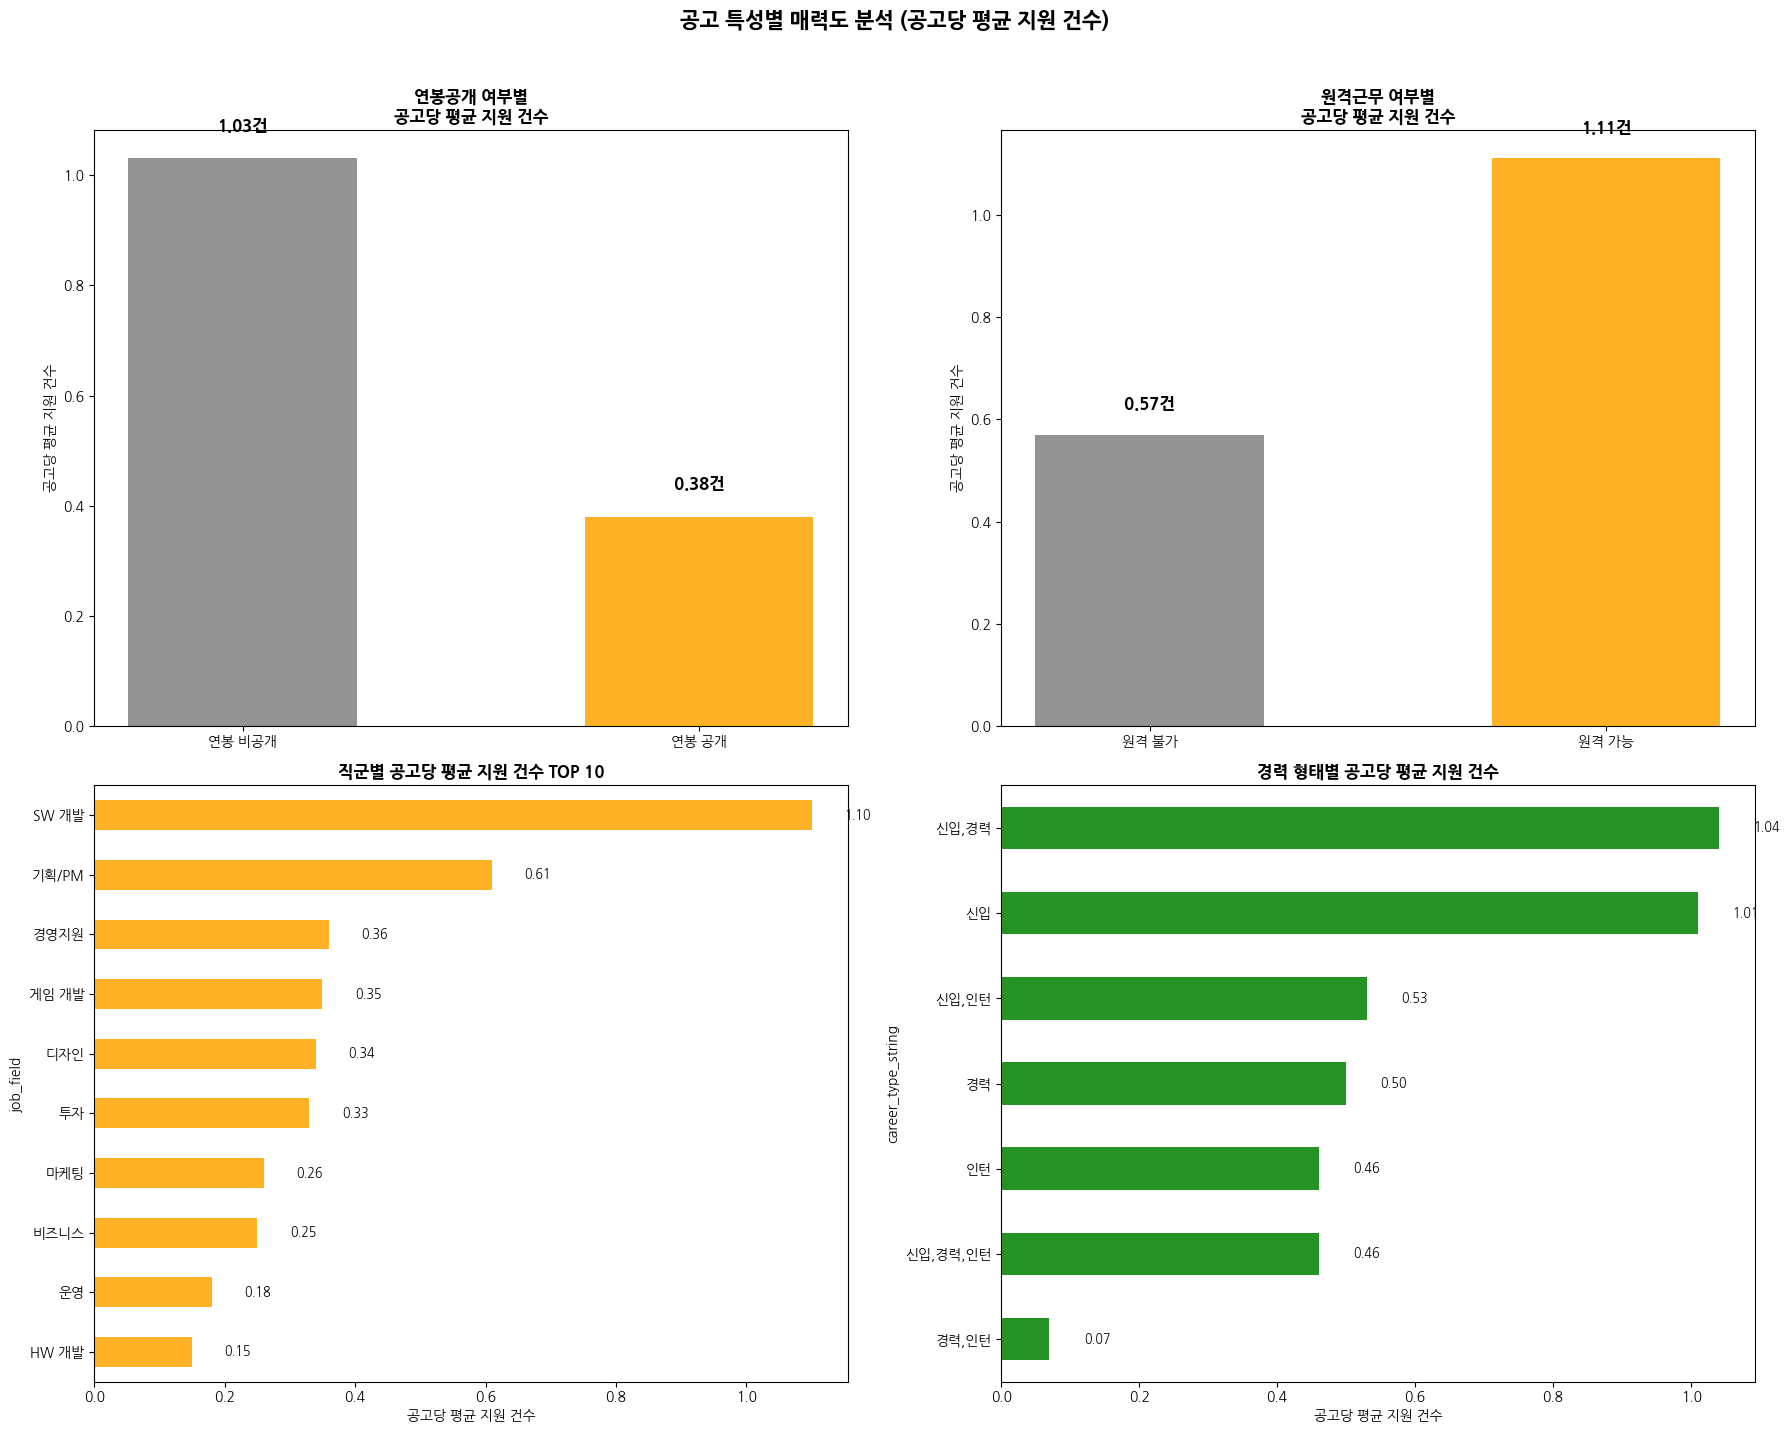

In [16]:
# =========================================================================
# 공고당 평균 지원 건수 분석
# (지원 건수 / 공고 수 = 공고 매력도)
# =========================================================================

# =========================================================================
# 1. 연봉공개 여부별 공고당 평균 지원 건수
# =========================================================================

# 전체 공고 수 (job 테이블 기준)
job_salary_total = job['can_show_salary'].value_counts()

# 실제 지원된 공고별 지원 건수
salary_apply = (
    app_job.groupby('can_show_salary')['job_uuid']
    .count()
    .reset_index()
)
salary_apply.columns = ['can_show_salary', 'apply_count']

# 공고 수 병합
salary_apply['job_count'] = salary_apply['can_show_salary'].map(job_salary_total)
salary_apply['apply_per_job'] = (salary_apply['apply_count'] / salary_apply['job_count']).round(2)
salary_apply['label'] = salary_apply['can_show_salary'].map({0: '연봉 비공개', 1: '연봉 공개'})

print("=== 연봉공개 여부별 공고당 평균 지원 건수 ===")
print(salary_apply[['label', 'job_count', 'apply_count', 'apply_per_job']])

# =========================================================================
# 2. 원격근무 여부별 공고당 평균 지원 건수
# =========================================================================

job_remote_total = job['allow_remote'].value_counts()

remote_apply = (
    app_job.groupby('allow_remote')['job_uuid']
    .count()
    .reset_index()
)
remote_apply.columns = ['allow_remote', 'apply_count']
remote_apply['job_count']     = remote_apply['allow_remote'].map(job_remote_total)
remote_apply['apply_per_job'] = (remote_apply['apply_count'] / remote_apply['job_count']).round(2)
remote_apply['label']         = remote_apply['allow_remote'].map({0: '원격 불가', 1: '원격 가능'})

print("\n=== 원격근무 여부별 공고당 평균 지원 건수 ===")
print(remote_apply[['label', 'job_count', 'apply_count', 'apply_per_job']])

# =========================================================================
# 3. 직군별 공고당 평균 지원 건수
# =========================================================================

job_field_total = job['job_field'].value_counts()

field_apply = (
    app_job.groupby('job_field')['job_uuid']
    .count()
    .reset_index()
)
field_apply.columns = ['job_field', 'apply_count']
field_apply['job_count']     = field_apply['job_field'].map(job_field_total)
field_apply['apply_per_job'] = (field_apply['apply_count'] / field_apply['job_count']).round(2)
field_apply = field_apply.sort_values('apply_per_job', ascending=False)

print("\n=== 직군별 공고당 평균 지원 건수 ===")
print(field_apply[['job_field', 'job_count', 'apply_count', 'apply_per_job']].head(10))

# =========================================================================
# 4. 경력 형태별 공고당 평균 지원 건수
# =========================================================================

job_career_total = job['career_type_string'].value_counts()

career_apply = (
    app_job.groupby('career_type_string')['job_uuid']
    .count()
    .reset_index()
)
career_apply.columns = ['career_type_string', 'apply_count']
career_apply['job_count']     = career_apply['career_type_string'].map(job_career_total)
career_apply['apply_per_job'] = (career_apply['apply_count'] / career_apply['job_count']).round(2)
career_apply = career_apply.sort_values('apply_per_job', ascending=False)

print("\n=== 경력 형태별 공고당 평균 지원 건수 ===")
print(career_apply[['career_type_string', 'job_count', 'apply_count', 'apply_per_job']])

# =========================================================================
# 시각화
# =========================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 연봉공개 여부
bars = axes[0][0].bar(
    salary_apply['label'],
    salary_apply['apply_per_job'],
    color=['gray', 'orange'], alpha=0.85, width=0.5
)
for bar, val in zip(bars, salary_apply['apply_per_job']):
    axes[0][0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'{val:.2f}건',
                    ha='center', fontweight='bold', fontsize=12)
axes[0][0].set_ylabel('공고당 평균 지원 건수')
axes[0][0].set_title('연봉공개 여부별\n공고당 평균 지원 건수',
                      fontsize=12, fontweight='bold')

# 원격근무 여부
bars2 = axes[0][1].bar(
    remote_apply['label'],
    remote_apply['apply_per_job'],
    color=['gray', 'orange'], alpha=0.85, width=0.5
)
for bar, val in zip(bars2, remote_apply['apply_per_job']):
    axes[0][1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'{val:.2f}건',
                    ha='center', fontweight='bold', fontsize=12)
axes[0][1].set_ylabel('공고당 평균 지원 건수')
axes[0][1].set_title('원격근무 여부별\n공고당 평균 지원 건수',
                      fontsize=12, fontweight='bold')

# 직군별
field_apply.head(10).sort_values('apply_per_job').plot(
    kind='barh', x='job_field', y='apply_per_job',
    ax=axes[1][0], color='orange', alpha=0.85, legend=False
)
for i, val in enumerate(field_apply.head(10).sort_values('apply_per_job')['apply_per_job']):
    axes[1][0].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)
axes[1][0].set_xlabel('공고당 평균 지원 건수')
axes[1][0].set_title('직군별 공고당 평균 지원 건수 TOP 10',
                      fontsize=12, fontweight='bold')

# 경력 형태별
career_apply.sort_values('apply_per_job').plot(
    kind='barh', x='career_type_string', y='apply_per_job',
    ax=axes[1][1], color='green', alpha=0.85, legend=False
)
for i, val in enumerate(career_apply.sort_values('apply_per_job')['apply_per_job']):
    axes[1][1].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)
axes[1][1].set_xlabel('공고당 평균 지원 건수')
axes[1][1].set_title('경력 형태별 공고당 평균 지원 건수',
                      fontsize=12, fontweight='bold')

plt.suptitle('공고 특성별 매력도 분석 (공고당 평균 지원 건수)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# 실제 지원된 공고 수
applied_jobs = app_job['job_uuid'].nunique()
total_jobs   = len(job)

print(f"전체 공고 수: {total_jobs:,}개")
print(f"지원된 공고 수: {applied_jobs:,}개")
print(f"지원된 공고 비율: {applied_jobs/total_jobs*100:.1f}%")

전체 공고 수: 139,764개
지원된 공고 수: 18,575개
지원된 공고 비율: 13.3%


지원된 공고 수: 17,798개

=== 연봉공개 여부별 공고당 평균 지원 건수 ===
                 mean  median  count
can_show_salary                     
연봉 비공개           4.79     2.0  11971
연봉 공개            5.45     2.0   5827

=== 원격근무 여부별 공고당 평균 지원 건수 ===
              mean  median  count
allow_remote                     
원격 불가         4.99     2.0  14030
원격 가능         5.09     2.0   3768

=== 직군별 공고당 평균 지원 건수 ===
           mean  median  count
job_field                     
SW 개발      7.25     3.0   8664
기획/PM      3.53     2.0   1971
디자인        3.08     2.0   2124
비즈니스       2.78     2.0    903
마케팅        2.55     2.0   1956
운영         2.51     2.0    997
게임 개발      2.48     2.0     88
경영지원       2.43     2.0    942
투자         2.11     1.0     63
HW 개발      1.73     1.0     90

=== 경력 형태별 공고당 평균 지원 건수 ===
                    mean  median  count
career_type_string                     
신입,경력,인턴            6.84     3.0   1353
신입                  6.51     2.0    494
신입,경력               6.49     2.0   5658
신입,인턴    

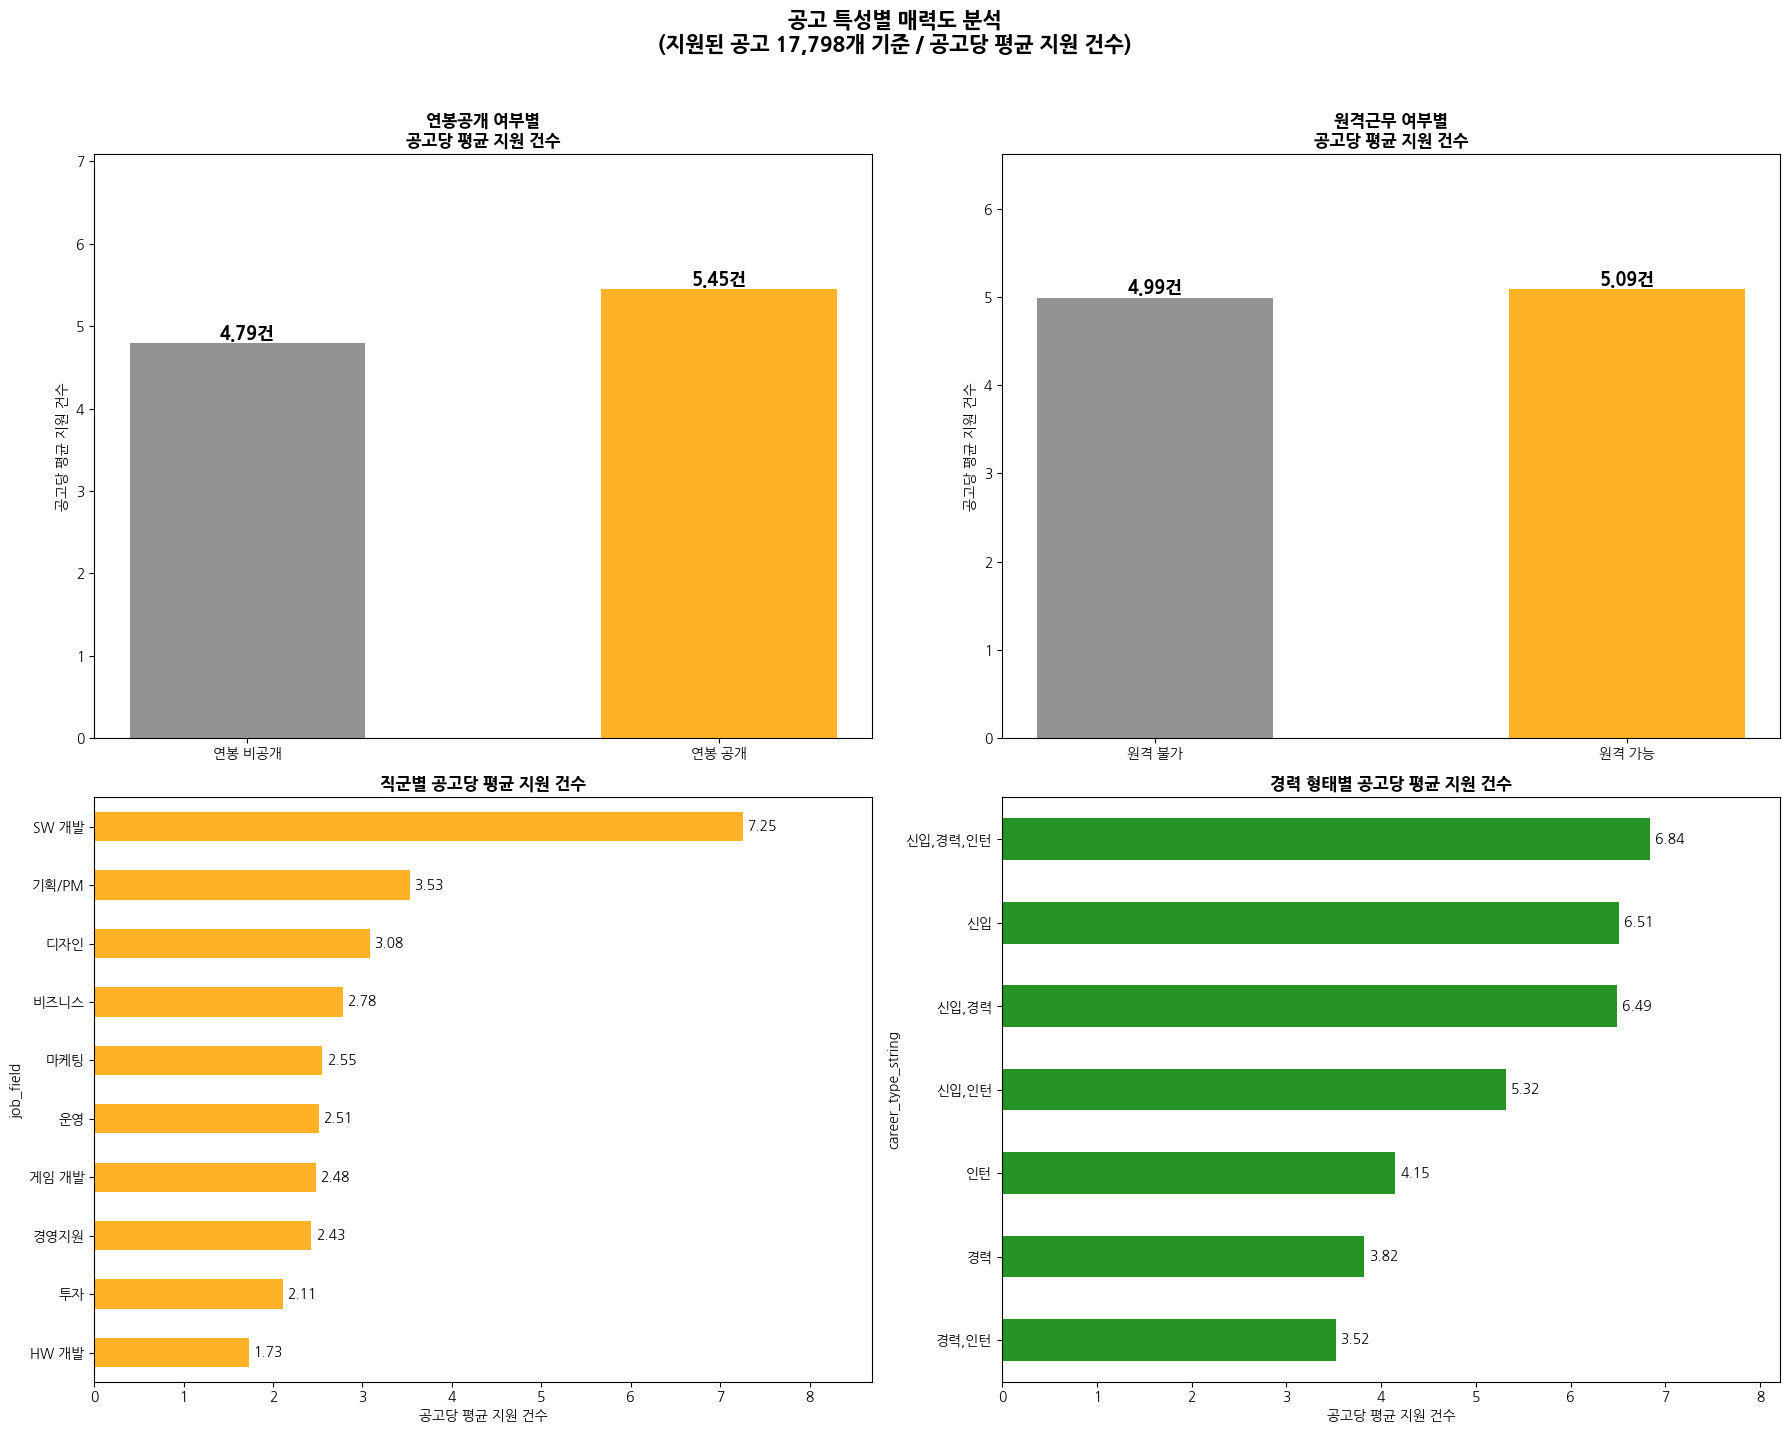

In [17]:
# =========================================================================
# 지원된 공고만 기준으로 공고당 평균 지원 건수
# =========================================================================

# 지원된 공고만 추출
applied_job_info = app_job.dropna(subset=['job_field']).copy()

# 공고별 지원 건수
job_apply_count = (
    applied_job_info.groupby('job_uuid')
    .size()
    .reset_index()
)
job_apply_count.columns = ['job_uuid', 'apply_count']

# job 테이블과 병합
job_apply_count = job_apply_count.merge(
    job[['job_uuid', 'job_field', 'career_type_string',
         'allow_remote', 'can_show_salary']],
    on='job_uuid', how='left'
)

print(f"지원된 공고 수: {len(job_apply_count):,}개")
print(f"\n=== 연봉공개 여부별 공고당 평균 지원 건수 ===")
print(job_apply_count.groupby('can_show_salary')['apply_count']
      .agg(['mean', 'median', 'count']).round(2)
      .rename(index={0: '연봉 비공개', 1: '연봉 공개'}))

print(f"\n=== 원격근무 여부별 공고당 평균 지원 건수 ===")
print(job_apply_count.groupby('allow_remote')['apply_count']
      .agg(['mean', 'median', 'count']).round(2)
      .rename(index={0: '원격 불가', 1: '원격 가능'}))

print(f"\n=== 직군별 공고당 평균 지원 건수 ===")
print(job_apply_count.groupby('job_field')['apply_count']
      .agg(['mean', 'median', 'count'])
      .round(2)
      .sort_values('mean', ascending=False))

print(f"\n=== 경력 형태별 공고당 평균 지원 건수 ===")
print(job_apply_count.groupby('career_type_string')['apply_count']
      .agg(['mean', 'median', 'count'])
      .round(2)
      .sort_values('mean', ascending=False))

# =========================================================================
# 공고 특성별 매력도 시각화
# =========================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. 연봉공개 여부별
salary_data = job_apply_count.groupby('can_show_salary')['apply_count'].mean().round(2)
salary_labels = {0: '연봉 비공개', 1: '연봉 공개'}
salary_values = [salary_data.get(0, 0), salary_data.get(1, 0)]
salary_names  = ['연봉 비공개', '연봉 공개']

bars = axes[0][0].bar(salary_names, salary_values,
                      color=['gray', 'orange'], alpha=0.85, width=0.5)
for bar, val in zip(bars, salary_values):
    axes[0][0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'{val:.2f}건',
                    ha='center', fontweight='bold', fontsize=13)
axes[0][0].set_ylabel('공고당 평균 지원 건수')
axes[0][0].set_ylim(0, max(salary_values) * 1.3)
axes[0][0].set_title('연봉공개 여부별\n공고당 평균 지원 건수',
                      fontsize=12, fontweight='bold')

# 2. 원격근무 여부별
remote_data   = job_apply_count.groupby('allow_remote')['apply_count'].mean().round(2)
remote_values = [remote_data.get(0, 0), remote_data.get(1, 0)]
remote_names  = ['원격 불가', '원격 가능']

bars2 = axes[0][1].bar(remote_names, remote_values,
                       color=['gray', 'orange'], alpha=0.85, width=0.5)
for bar, val in zip(bars2, remote_values):
    axes[0][1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'{val:.2f}건',
                    ha='center', fontweight='bold', fontsize=13)
axes[0][1].set_ylabel('공고당 평균 지원 건수')
axes[0][1].set_ylim(0, max(remote_values) * 1.3)
axes[0][1].set_title('원격근무 여부별\n공고당 평균 지원 건수',
                      fontsize=12, fontweight='bold')

# 3. 직군별
field_data = (
    job_apply_count.groupby('job_field')['apply_count']
    .mean()
    .round(2)
    .sort_values(ascending=True)
)
field_data.plot(kind='barh', ax=axes[1][0], color='orange', alpha=0.85)
for i, val in enumerate(field_data):
    axes[1][0].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10)
axes[1][0].set_xlabel('공고당 평균 지원 건수')
axes[1][0].set_xlim(0, field_data.max() * 1.2)
axes[1][0].set_title('직군별 공고당 평균 지원 건수',
                      fontsize=12, fontweight='bold')

# 4. 경력 형태별
career_data = (
    job_apply_count.groupby('career_type_string')['apply_count']
    .mean()
    .round(2)
    .sort_values(ascending=True)
)
career_data.plot(kind='barh', ax=axes[1][1], color='green', alpha=0.85)
for i, val in enumerate(career_data):
    axes[1][1].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10)
axes[1][1].set_xlabel('공고당 평균 지원 건수')
axes[1][1].set_xlim(0, career_data.max() * 1.2)
axes[1][1].set_title('경력 형태별 공고당 평균 지원 건수',
                      fontsize=12, fontweight='bold')

plt.suptitle('공고 특성별 매력도 분석\n(지원된 공고 17,798개 기준 / 공고당 평균 지원 건수)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== 네트워킹 세그먼트별 공고 특성 ===

1. 네트워크 핵심 (66,449건)
  직군 TOP3: {'SW 개발': 46044, '기획/PM': 4926, '디자인': 4904}
  연봉공개: {0.0: 64.9, 1.0: 35.1}
  원격가능: {0.0: 78.6, 1.0: 21.4}
  경력형태 TOP3: {'경력': 26757, '신입,경력': 26384, '신입,경력,인턴': 6499}

2. 탐색형 (3,066건)
  직군 TOP3: {'SW 개발': 1749, '기획/PM': 304, '디자인': 264}
  연봉공개: {0.0: 66.8, 1.0: 33.2}
  원격가능: {0.0: 79.8, 1.0: 20.2}
  경력형태 TOP3: {'신입,경력': 1196, '경력': 1131, '신입,경력,인턴': 352}

4. 관망형 (1,288건)
  직군 TOP3: {'SW 개발': 777, '디자인': 160, '기획/PM': 90}
  연봉공개: {0.0: 67.0, 1.0: 33.0}
  원격가능: {0.0: 79.2, 1.0: 20.8}
  경력형태 TOP3: {'경력': 518, '신입,경력': 473, '신입,경력,인턴': 131}

=== 구직활동 세그먼트별 공고 특성 ===

1. 적극적 구직자 (69,383건)
  직군 TOP3: {'SW 개발': 47730, '디자인': 5250, '기획/PM': 5144}
  연봉공개: {0.0: 65.1, 1.0: 34.9}
  원격가능: {0.0: 78.7, 1.0: 21.3}
  경력형태 TOP3: {'경력': 27805, '신입,경력': 27603, '신입,경력,인턴': 6810}

2. 탐색형 구직자 (1,470건)
  직군 TOP3: {'SW 개발': 964, '기획/PM': 154, '디자인': 77}
  연봉공개: {0.0: 65.2, 1.0: 34.8}
  원격가능: {0.0: 79.2, 1.0: 20.8}
  경력형태 TOP3: {'경력': 561, '신입,경력': 559

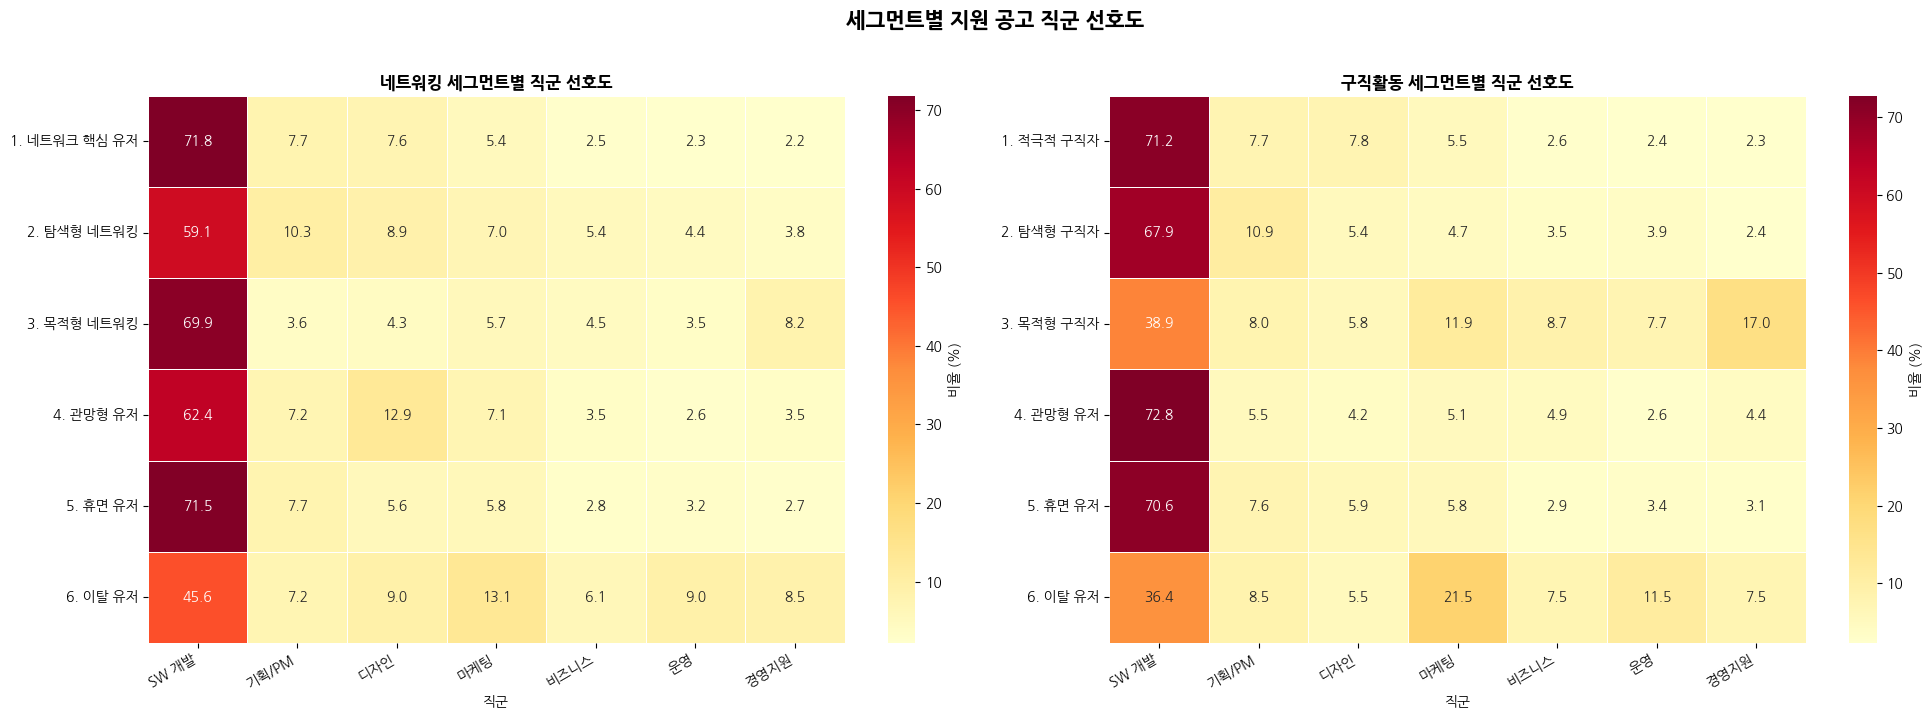

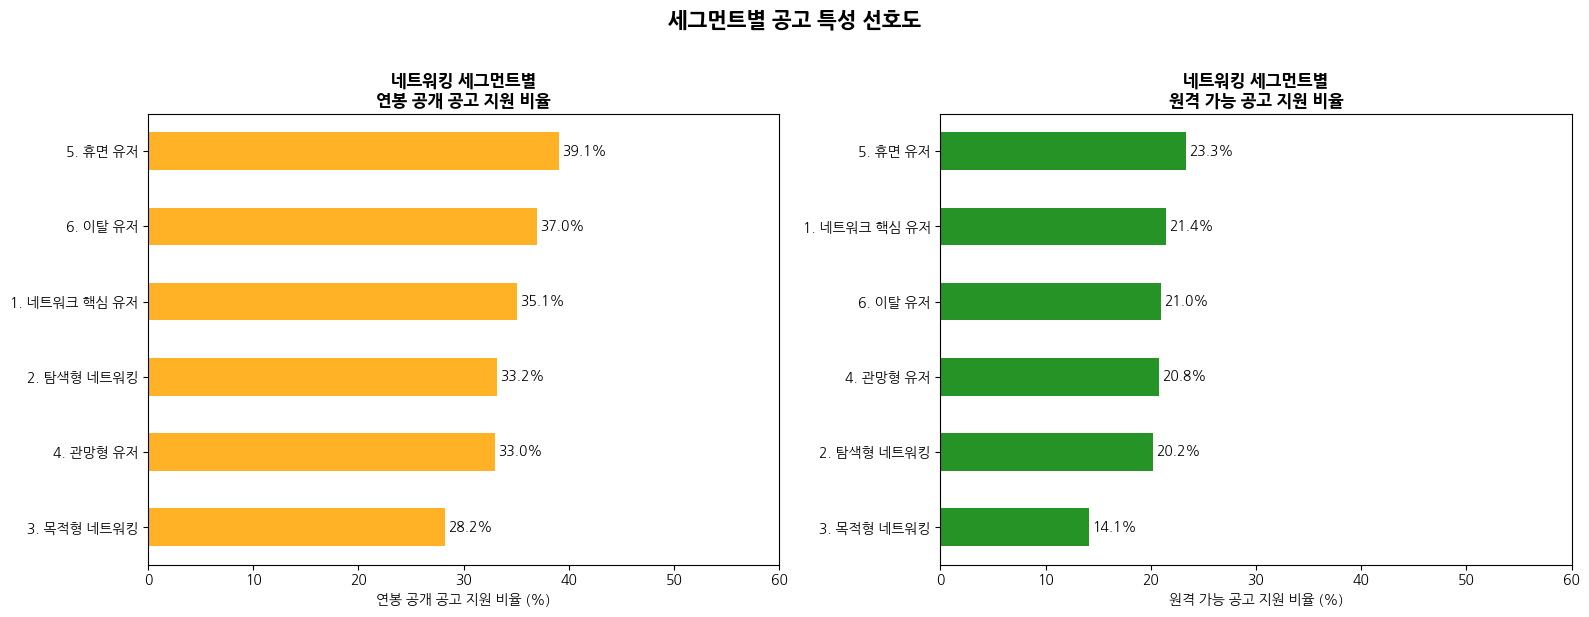

In [18]:
# =========================================================================
# 유저 세그먼트별 선호 공고 특성 분석
# =========================================================================

# 네트워킹 세그먼트별 공고 특성
print("=== 네트워킹 세그먼트별 공고 특성 ===")

target_segments = {
    '1. 네트워크 핵심':  '1. 네트워크 핵심 유저 (The Connector)',
    '2. 탐색형':        '2. 탐색형 네트워킹 (The Observer)',
    '4. 관망형':        '4. 관망형 유저 (The Lurker)',
}

for label, seg in target_segments.items():
    group = app_job[app_job['network_segment'] == seg]
    total = len(group)
    print(f"\n{label} ({total:,}건)")
    print(f"  직군 TOP3: {group['job_field'].value_counts().head(3).to_dict()}")
    print(f"  연봉공개: {group['can_show_salary'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
    print(f"  원격가능: {group['allow_remote'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
    print(f"  경력형태 TOP3: {group['career_type_string'].value_counts().head(3).to_dict()}")

# =========================================================================
# 구직활동 세그먼트별 공고 특성
# =========================================================================

print("\n=== 구직활동 세그먼트별 공고 특성 ===")

job_segments = {
    '1. 적극적 구직자': '1. 적극적 구직자 (The Active)',
    '2. 탐색형 구직자': '2. 탐색형 구직자 (The Browser)',
    '4. 관망형':        '4. 관망형 유저 (The Lurker)',
}

for label, seg in job_segments.items():
    group = app_job[app_job['job_segment'] == seg]
    total = len(group)
    print(f"\n{label} ({total:,}건)")
    print(f"  직군 TOP3: {group['job_field'].value_counts().head(3).to_dict()}")
    print(f"  연봉공개: {group['can_show_salary'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
    print(f"  원격가능: {group['allow_remote'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
    print(f"  경력형태 TOP3: {group['career_type_string'].value_counts().head(3).to_dict()}")

# =========================================================================
# 시각화: 세그먼트별 직군 선호도 히트맵
# =========================================================================

# 네트워킹 세그먼트별 직군 비율
net_field = pd.crosstab(
    app_job['network_segment'],
    app_job['job_field'],
    normalize='index'
).mul(100).round(1)

# 주요 직군만
top_fields = ['SW 개발', '기획/PM', '디자인', '마케팅', '비즈니스', '운영', '경영지원']
net_field = net_field[
    [col for col in top_fields if col in net_field.columns]
]

# 인덱스 짧게
net_field.index = [x.split('(')[0].strip() for x in net_field.index]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(
    net_field,
    annot=True, fmt='.1f', cmap='YlOrRd',
    ax=axes[0], linewidths=0.5,
    cbar_kws={'label': '비율 (%)'}
)
axes[0].set_title('네트워킹 세그먼트별 직군 선호도',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('직군')
axes[0].set_ylabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# 구직활동 세그먼트별 직군 비율
job_field_cross = pd.crosstab(
    app_job['job_segment'],
    app_job['job_field'],
    normalize='index'
).mul(100).round(1)

job_field_cross = job_field_cross[
    [col for col in top_fields if col in job_field_cross.columns]
]
job_field_cross.index = [x.split('(')[0].strip() for x in job_field_cross.index]

sns.heatmap(
    job_field_cross,
    annot=True, fmt='.1f', cmap='YlOrRd',
    ax=axes[1], linewidths=0.5,
    cbar_kws={'label': '비율 (%)'}
)
axes[1].set_title('구직활동 세그먼트별 직군 선호도',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('직군')
axes[1].set_ylabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('세그먼트별 지원 공고 직군 선호도',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# 시각화 2: 연봉공개 + 원격 여부별 세그먼트 비교
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 연봉공개 비율
salary_seg = pd.crosstab(
    app_job['network_segment'],
    app_job['can_show_salary'],
    normalize='index'
).mul(100).round(1)
salary_seg.columns = ['연봉 비공개', '연봉 공개']
salary_seg.index = [x.split('(')[0].strip() for x in salary_seg.index]

salary_seg['연봉 공개'].sort_values().plot(
    kind='barh', ax=axes[0], color='orange', alpha=0.85
)
for i, val in enumerate(salary_seg['연봉 공개'].sort_values()):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('연봉 공개 공고 지원 비율 (%)')
axes[0].set_xlim(0, 60)
axes[0].set_title('네트워킹 세그먼트별\n연봉 공개 공고 지원 비율',
                   fontsize=12, fontweight='bold')

# 원격 가능 비율
remote_seg = pd.crosstab(
    app_job['network_segment'],
    app_job['allow_remote'],
    normalize='index'
).mul(100).round(1)
remote_seg.columns = ['원격 불가', '원격 가능']
remote_seg.index = [x.split('(')[0].strip() for x in remote_seg.index]

remote_seg['원격 가능'].sort_values().plot(
    kind='barh', ax=axes[1], color='green', alpha=0.85
)
for i, val in enumerate(remote_seg['원격 가능'].sort_values()):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=10)
axes[1].set_xlabel('원격 가능 공고 지원 비율 (%)')
axes[1].set_xlim(0, 60)
axes[1].set_title('네트워킹 세그먼트별\n원격 가능 공고 지원 비율',
                   fontsize=12, fontweight='bold')

plt.suptitle('세그먼트별 공고 특성 선호도',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#회사(company 테이블)

In [19]:
# =========================================================================
# 기업 클러스터링 테이블 로드
# =========================================================================

company_cluster = pd.read_csv(
    '/content/drive/MyDrive/기업_클러스터링.csv',
    on_bad_lines='skip', low_memory=False
)

print(f"기업 클러스터링 데이터: {len(company_cluster):,}행")
print(f"\n컬럼: {company_cluster.columns.tolist()}")
print(f"\n샘플:")
display(company_cluster.head())
print(f"\n클러스터 분포:")
print(company_cluster.iloc[:, -1].value_counts())  # 마지막 컬럼이 클러스터일 가능성

기업 클러스터링 데이터: 41,612행

컬럼: ['cdate', 'mdate', 'found_date', 'employee_count', 'view_count', 'follow_count', 'reference_count', 'company_uuid', 'job_count', 'invest', 'address', 'job', 'pop_cluster', 'pop_cluster_name', 'manage_cluster', 'manage_cluster_name', 'manage_cluster_x', 'manage_cluster_name_x', 'bookmark_count', 'application_count']

샘플:


,cdate,mdate,found_date,employee_count,view_count,follow_count,reference_count,company_uuid,job_count,invest,address,job,pop_cluster,pop_cluster_name,manage_cluster,manage_cluster_name,manage_cluster_x,manage_cluster_name_x,bookmark_count,application_count
0,2022-06-09 04:08:40,2022-06-09 04:08:40,NaN,0명,0,0,0,c46f2fa5-f940-40fb-bd4a-aa0ff7a837fd,0,0,0,0,2,저인기형,0,미관리형,0,미등록형,0,0
1,2017-05-22 10:57:12,2022-07-25 00:12:02,NaN,0명,256,0,0,725e87bb-de2f-416a-a6b8-1ca8d0d096e0,0,0,0,0,0,조회형,0,미관리형,0,미등록형,0,0
2,2017-11-14 11:42:55,2022-11-04 03:29:16,NaN,0명,256,0,0,efa3747d-9bbd-4c84-af51-82ccf6545dcd,0,0,0,0,0,조회형,0,미관리형,0,미등록형,0,0
3,2017-11-27 10:59:30,2021-01-17 14:42:06,NaN,0명,256,0,0,84aa2c20-d0f3-4ec3-ac06-1ef67e071b8f,0,0,0,0,0,조회형,0,미관리형,0,미등록형,0,0
4,2018-01-08 14:41:58,2022-07-25 01:34:16,2018-01-08,0명,256,0,0,761e76b3-507c-4c8f-b96f-fa47a8ccb5f2,0,0,0,0,0,조회형,0,미관리형,0,미등록형,0,0



클러스터 분포:
application_count
0      31912
1       1564
2       1122
3        723
4        509
       ...  
169        1
439        1
585        1
295        1
846        1
Name: count, Length: 409, dtype: int64
